# Tennis Doubles Homophily — Main Analysis

Data: Grand Slam doubles matches 2018–2025 (2020: Wimbledon cancelled; AO/RG/USO included). N updated after pipeline re-run.

Sections:
1. Variable construction
2. Pressure outcomes (tiebreaks, comebacks)
3. Olympic cycle descriptive evidence
4. Baseline regressions — match win / tiebreak win / comeback win

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from getpass import getuser


pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

user = getuser()
df = pd.read_excel(f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx')
print(f'Loaded {df.shape[0]:,} matches | years: {sorted(df["year"].unique())}')

# Qualifying-round exclusion (Wimbledon 2018's 12 qualifying-round rows, see
# CLAUDE.md's "Sample correction" note) moved 2026-09-11 to code/cleaning/final_ds.ipynb,
# so men_matches_with_ranks_cleaned.xlsx is already qualifying-round-free -- no filter
# needed here anymore. This assertion just confirms that stayed true.
assert not df['stage'].str.contains('Qualifying', na=False).any(),     'Qualifying-round rows found -- men_matches_with_ranks_cleaned.xlsx should already be filtered (see final_ds.ipynb)'

Loaded 1,985 matches | years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


### 1a. Continuous Linguistic Proximity (prox1 + PSW2024 robustness measures)

Now merged upstream in `code/cleaning/final_ds.ipynb` and loaded directly from `men_matches_with_ranks_cleaned.xlsx` -- see that notebook for the lookup construction.


In [2]:
# ── Continuous linguistic-proximity measures ──────────────────────────────────
# The per-match winners/losers columns (prox1 + PSW2024) are built upstream in
# code/cleaning/final_ds.ipynb and already baked into men_matches_with_ranks_cleaned.xlsx.
#
# The only thing still needed here is a country-pair LOOKUP for Section 6/6.1/6.2's
# closed-form random-matching benchmark and field-composition calculations, which query
# arbitrary same-tournament country pairs (e.g. player A vs. every other field entrant C,
# even when A and C never actually played on a team together) -- not just the specific
# pairs already realized as actual matches, so this can't be pre-baked into the Excel the
# way the match-level columns can. That lookup is now itself a "final dataset": built and
# fully resolved (Monaco/KOR fallback already applied, no further logic needed) in
# code/merging/merge_linguistic_proximity.ipynb, exported to
# data/gravity/ling_prox_pairs_final.csv. This cell just loads it -- no raw Melitz-Toubal data,
# no fallback logic, here anymore.

_prox1_pairs = pd.read_csv(f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/gravity/ling_prox_pairs_final.csv')
_prox1_lut = {
    tuple(sorted([a, b])): v
    for a, b, v in zip(_prox1_pairs['iso3_a'], _prox1_pairs['iso3_b'], _prox1_pairs['prox1'])
}

def _prox1_lookup(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    return _prox1_lut.get(tuple(sorted([str(a).upper(), str(b).upper()])), np.nan)

# Sanity check: the per-match columns already on df (from final_ds.ipynb) should agree
# with a fresh _prox1_lookup call on the same pairs.
_cont_cols = ['winners_ling_prox_cont', 'losers_ling_prox_cont',
              'winners_ling_prox_psw_tree', 'losers_ling_prox_psw_tree',
              'winners_ling_prox_psw_cognet', 'losers_ling_prox_psw_cognet']
for _col in _cont_cols:
    print(f'  {_col:<32s} coverage: {df[_col].notna().sum():,} / {len(df):,} '
          f'({100*df[_col].notna().mean():.1f}%)  mean={df[_col].mean():.3f}')


  winners_ling_prox_cont           coverage: 1,985 / 1,985 (100.0%)  mean=0.666
  losers_ling_prox_cont            coverage: 1,985 / 1,985 (100.0%)  mean=0.661
  winners_ling_prox_psw_tree       coverage: 1,985 / 1,985 (100.0%)  mean=0.642
  losers_ling_prox_psw_tree        coverage: 1,985 / 1,985 (100.0%)  mean=0.639
  winners_ling_prox_psw_cognet     coverage: 1,985 / 1,985 (100.0%)  mean=0.653
  losers_ling_prox_psw_cognet      coverage: 1,985 / 1,985 (100.0%)  mean=0.644


In [3]:
# ── Missing data: key regression variables ──────────────────────────────
KEY_VARS = {
    'Country (raw)':       ['winners_p1_country',  'winners_p2_country',
                            'losers_p1_country',   'losers_p2_country'],
    'ISO3 code':           ['winners_p1_iso3',     'winners_p2_iso3',
                            'losers_p1_iso3',      'losers_p2_iso3'],
    'Same country':        ['same_country_winners', 'same_country_losers'],
    'Same language':       ['winners_same_language', 'losers_same_language'],
    'Ling. proximity':     ['winners_linguistic_proximity', 'losers_linguistic_proximity'],
    'Doubles rank':        ['winners_p1_rank_num',  'winners_p2_rank_num',
                            'losers_p1_rank_num',   'losers_p2_rank_num'],
    'Years since turning pro':   ['winners_p1_experience_double', 'winners_p2_experience_double',
                            'losers_p1_experience_double',  'losers_p2_experience_double'],
    'Singles career high': ['winners_p1_singles_career_high_rank_num',
                            'winners_p2_singles_career_high_rank_num',
                            'losers_p1_singles_career_high_rank_num',
                            'losers_p2_singles_career_high_rank_num'],
}

n = len(df)
print(f'Dataset: {n:,} matches\n')
print(f'{"Variable group":<25} {"Cols":<6} {"NaN slots":<12} {"Matches with any NaN"}')
print('-' * 62)
for grp, cols in KEY_VARS.items():
    existing  = [c for c in cols if c in df.columns]
    nan_total = sum(df[c].isna().sum() for c in existing)
    any_nan   = df[existing].isna().any(axis=1).sum()
    print(f'{grp:<25} {len(existing):<6} {nan_total:<12} {any_nan:,}  ({100*any_nan/n:.1f}%)')


Dataset: 1,985 matches

Variable group            Cols   NaN slots    Matches with any NaN
--------------------------------------------------------------
Country (raw)             4      0            0  (0.0%)
ISO3 code                 4      0            0  (0.0%)
Same country              2      0            0  (0.0%)
Same language             2      0            0  (0.0%)
Ling. proximity           2      0            0  (0.0%)
Doubles rank              4      10           10  (0.5%)
Years since turning pro   4      1003         676  (34.1%)
Singles career high       4      168          165  (8.3%)


## 1. Variable Construction

In [4]:
# ── Tiebreak flags ────────────────────────────────────────
# Drop likely retirements/walkovers: matches where set scores are missing
# or incomplete, indicating the match did not finish normally.
def regular_set_complete(w, l):
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (
        ((hi == 6) & (lo <= 4)) |
        ((hi == 7) & lo.isin([5, 6])) |
        ((hi >= 8) & ((hi - lo) == 2))
    )

def match_tiebreak_complete(w, l):
    # Long advantage-set / 10-pt super-tiebreak signature: no breaker at 6-6, so
    # play continues past 7 games. Threshold is hi >= 8 (not 10): genuine long
    # finishes like 8-6 or 9-7 are just as much "no breaker" deciders as 10-8 or
    # a real super-tiebreak score like 10-5 (margin can exceed 2 there, hence
    # ">= 2" rather than "== 2"). Previously required hi >= 10, which silently
    # missed 7 genuine cases (4 at set 3, 3 at set 5) that regular_set_complete's
    # own hi >= 8 branch already recognized as complete.
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (hi >= 8) & ((hi - lo) >= 2)

def breaker_12_12_complete(w, l):
    # Deciding set reaches 12-12, then a breaker decides it (e.g. 13-12) -- a
    # real, historical Wimbledon final-set rule. A 1-game margin, so it is NOT
    # caught by regular_set_complete (requires a 2-game margin) or
    # match_tiebreak_complete (requires hi - lo >= 2).
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (lo == 12) & ((hi - lo) == 1)

def valid_set_score(w, l):
    return regular_set_complete(w, l) | match_tiebreak_complete(w, l) | breaker_12_12_complete(w, l)

s1_complete = valid_set_score(df['winners_set1'], df['losers_set1'])
s2_complete = valid_set_score(df['winners_set2'], df['losers_set2'])
split_sets = (
    ((df['winners_set1'] > df['losers_set1']) & (df['winners_set2'] < df['losers_set2'])) |
    ((df['winners_set1'] < df['losers_set1']) & (df['winners_set2'] > df['losers_set2']))
)
s3_complete = valid_set_score(df['winners_set3'], df['losers_set3'])
# Sets 4-5 (best-of-5 matches only): if played, must also be a valid/complete
# score -- this catches genuine mid-set retirements in set 4/5 (e.g. an
# incomplete score like 4-3 or 1-1) that a sets-1-3-only check would miss.
s4_valid = df['winners_set4'].isna() | valid_set_score(df['winners_set4'], df['losers_set4'])
s5_valid = df['winners_set5'].isna() | valid_set_score(df['winners_set5'], df['losers_set5'])

retired_or_incomplete = ~s1_complete | ~s2_complete | (split_sets & ~s3_complete) | ~s4_valid | ~s5_valid
print(f'Dropping likely retirements/walkovers: {retired_or_incomplete.sum():,} matches')

# ── Detail of dropped matches ───────────────────────────────────────
# Part 1 of this report is GS-only, so every count below is split GS vs.
# Olympics -- no Olympic number should ever be folded into a Part-1 figure.
# (olympics_tourn isn't created until later in this cell, so use the raw
# tournament column here.)
_is_olympics = df['tournament'] == 'Olympics'

def _classify_drop(row):
    w1, l1 = row.get('winners_set1'), row.get('losers_set1')
    w2, l2 = row.get('winners_set2'), row.get('losers_set2')
    if pd.isna(w1) and pd.isna(l1):
        return 'WALKOVER'
    if pd.notna(w1) and pd.notna(l1) and pd.notna(w2) and pd.notna(l2):
        return 'RETIREMENT-S2+'
    return 'RETIREMENT-S1'

_dropped = df[retired_or_incomplete].copy()
_dropped['drop_reason'] = _dropped.apply(_classify_drop, axis=1)
_dropped['is_olympics'] = (df.loc[retired_or_incomplete, 'tournament'] == 'Olympics').values

_gs_raw = int((~_is_olympics).sum())
_gs_dropped = int((retired_or_incomplete & ~_is_olympics).sum())
print()
print(f'GS raw (before any drops): {_gs_raw:,} matches')
print(f'GS retirements/walkovers dropped: {_gs_dropped:,}')
print(_dropped.loc[~_dropped['is_olympics'], 'drop_reason'].value_counts().to_string())
print(f'GS after retirement/walkover drop: {_gs_raw - _gs_dropped:,}')
print()
print(f'Olympics retirements/walkovers dropped: {int((retired_or_incomplete & _is_olympics).sum()):,}')
print(_dropped.loc[_dropped['is_olympics'], 'drop_reason'].value_counts().to_string())
_show = ['year', 'tournament', 'stage', 'drop_reason',
         'winners_p1_surname', 'winners_p2_surname',
         'losers_p1_surname',  'losers_p2_surname',
         'winners_set1', 'losers_set1',
         'winners_set2', 'losers_set2',
         'winners_set3', 'losers_set3']
_show = [c for c in _show if c in _dropped.columns]
print()
print(_dropped.sort_values('drop_reason')[_show].to_string(index=False))

df = df.loc[~retired_or_incomplete].copy()

# Regular 7-point tiebreak: set reaches 7-6
df['tb_s1'] = ((df['winners_set1']==7)&(df['losers_set1']==6)) | ((df['winners_set1']==6)&(df['losers_set1']==7))
df['tb_s2'] = ((df['winners_set2']==7)&(df['losers_set2']==6)) | ((df['winners_set2']==6)&(df['losers_set2']==7))
df['regular_tb']    = df['tb_s1'] | df['tb_s2']
df['tb_s3_regular'] = (((df['winners_set3']==7)&(df['losers_set3']==6)) | ((df['winners_set3']==6)&(df['losers_set3']==7))).fillna(False)

# Sets 4-5 only occur in the 103 best-of-5 Wimbledon matches (2018/2019/2021/2022,
# see section 2.1). Same 7-point standard-tiebreak pattern as sets 1-3.
df['tb_s4'] = (((df['winners_set4']==7)&(df['losers_set4']==6)) | ((df['winners_set4']==6)&(df['losers_set4']==7))).fillna(False)
df['tb_s5'] = (((df['winners_set5']==7)&(df['losers_set5']==6)) | ((df['winners_set5']==6)&(df['losers_set5']==7))).fillna(False)

# Match tiebreak / super-tiebreak (10-point) -- can occur as the deciding set,
# which is set 3 for a best-of-3 match but set 4 or set 5 for a best-of-5 match.
# match_tiebreak_complete requires both scores present, so this is naturally False
# for whichever of sets 4/5 a given match did not reach.
df['match_tb_s3'] = match_tiebreak_complete(df['winners_set3'], df['losers_set3'])
df['match_tb_s4'] = match_tiebreak_complete(df['winners_set4'], df['losers_set4'])
df['match_tb_s5'] = match_tiebreak_complete(df['winners_set5'], df['losers_set5'])
df['match_tb'] = df['match_tb_s3'] | df['match_tb_s4'] | df['match_tb_s5']
# Which set number the 10-pt/advantage-set decider actually occurred in (NaN if none)
df['match_tb_set'] = np.select(
    [df['match_tb_s3'], df['match_tb_s4'], df['match_tb_s5']], [3, 4, 5], default=np.nan
)
# any_std_tb: every literal 7-6 standard tiebreak, any set (1-5). Used for Table 4's
# main specification ("7pt tiebreak in any set"); any_tb additionally folds in the
# match_tb / advantage-set-decider category for the Table 4 robustness specification.
df['any_std_tb'] = df['tb_s1'] | df['tb_s2'] | df['tb_s3_regular'] | df['tb_s4'] | df['tb_s5']
df['any_tb']      = df['any_std_tb'] | df['match_tb']

# Who won each tiebreak (winner-team perspective)
df['w_won_tb_s1'] = df['tb_s1'] & (df['winners_set1'] == 7)
df['w_won_tb_s2'] = df['tb_s2'] & (df['winners_set2'] == 7)
df['w_won_tb_s3'] = df['tb_s3_regular'] & (df['winners_set3'] == 7)
df['w_won_tb_s4'] = df['tb_s4'] & (df['winners_set4'] == 7)
df['w_won_tb_s5'] = df['tb_s5'] & (df['winners_set5'] == 7)

# ── Match structure ───────────────────────────────────────────
df['three_sets']     = df['winners_set3'].notna()
df['winner_lost_s1'] = df['winners_set1'] < df['losers_set1']
df['comeback']       = df['winner_lost_s1'] & df['three_sets']

# ── Olympic period flags ──────────────────────────────────────
def get_period(row):
    y = row['year']
    t = row['tournament']
    if y in [2018, 2019]:
        return 'Pre-Tokyo'
    elif y == 2020:
        return 'Tokyo Prep' if t != 'Wimbledon' else None
    elif y == 2021:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Tokyo Prep'
        elif t == 'US Open':
            return 'Post-Tokyo'
    elif y == 2022:
        return 'Pre-Paris'
    elif y == 2023:
        return 'Paris Prep'
    elif y == 2024:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Paris Prep'
        elif t == 'US Open':
            return 'Post-Paris'
    elif y == 2025:
        return 'Post-Paris'
    return None

df['cycle'] = df.apply(get_period, axis=1)
df['pre_olympic']    = df['cycle'].isin(['Pre-Paris', 'Paris Prep']).astype(int)
df['olympic_period'] = df['cycle'].isin(['Pre-Paris', 'Paris Prep', 'Post-Paris']).astype(int)
df['olympics_tourn'] = (df['tournament'] == 'Olympics').astype(int)

# ── Match-level homophily differences and averages ───────────────────
df['same_country_diff']  = df['same_country_winners'].astype(float)  - df['same_country_losers'].astype(float)
df['same_language_diff'] = df['winners_same_language'].astype(float) - df['losers_same_language'].astype(float)
# ling_prox now means prox1 (continuous, Melitz & Toubal / Bekes-Ottaviano) throughout the
# main text, per 2026-09-10 decision; the old binary comlang_ethno measure and the PSW2024
# measures are kept under separate names for the Appendix.
df['ling_prox_diff']         = df['winners_ling_prox_cont'].astype(float) - df['losers_ling_prox_cont'].astype(float)
df['ling_prox_diff_binary']  = df['winners_linguistic_proximity'].astype(float) - df['losers_linguistic_proximity'].astype(float)

df['same_country_avg']  = (df['same_country_winners'] + df['same_country_losers']) / 2
df['same_language_avg'] = (df['winners_same_language'] + df['losers_same_language']) / 2
df['ling_prox_avg']         = (df['winners_ling_prox_cont'] + df['losers_ling_prox_cont']) / 2
df['ling_prox_avg_binary']  = (df['winners_linguistic_proximity'] + df['losers_linguistic_proximity']) / 2
print('Variable construction complete. NOTE: ling_prox / ling_prox_avg now mean prox1 (continuous).')


Dropping likely retirements/walkovers: 48 matches

GS raw (before any drops): 1,921 matches
GS retirements/walkovers dropped: 47
drop_reason
WALKOVER          19
RETIREMENT-S2+    18
RETIREMENT-S1     10
GS after retirement/walkover drop: 1,874

Olympics retirements/walkovers dropped: 1
drop_reason
WALKOVER    1

 year      tournament          stage    drop_reason winners_p1_surname winners_p2_surname losers_p1_surname losers_p2_surname  winners_set1  losers_set1  winners_set2  losers_set2  winners_set3  losers_set3
 2023   Roland Garros    Round of 32  RETIREMENT-S1                ram          salisbury             baena             munar        3.0000       2.0000           NaN          NaN           NaN          NaN
 2022 Australian Open    Round of 64  RETIREMENT-S1             sweeny                 tu           golubev            škugor        5.0000       2.0000           NaN          NaN           NaN          NaN
 2021       Wimbledon    Round of 16  RETIREMENT-S1          gör

Variable construction complete. NOTE: ling_prox / ling_prox_avg now mean prox1 (continuous).


## 2. Pressure Outcomes - Counts and Inspection

In [5]:
# Regression-sample match IDs: same ranking/nationality completeness filter used
# later in Section 4 (team panel construction), replicated here so the descriptive
# stats below match the actual regression sample exactly (not a broader pre-filter set).
_bad_rank_desc = df['rank_mean_winners'].isna() | df['rank_mean_losers'].isna()
_bad_nat_desc = (df[['same_country_winners','same_country_losers',
                      'winners_same_language','losers_same_language',
                      'winners_linguistic_proximity','losers_linguistic_proximity']]
                  .isna().any(axis=1))
_reg_match_ids = set(df.loc[~(_bad_rank_desc | _bad_nat_desc), 'match_id'])

df_gs_desc = df[(df['olympics_tourn'] == 0) & (df['match_id'].isin(_reg_match_ids))]
print(f'=== Table 1. Pressure Outcome Counts (Grand Slams regression sample, N={len(df_gs_desc):,}) ===')
# Only genuine tiebreaks: a standard 7-pt tiebreak (sets 1-5). Advantage-set deciders
# without a breaker (e.g. 8-6) are NOT tiebreaks -- no breaker was ever played, confirmed
# by the raw tiebreak-score columns being null for all 15 such cases (see section 2.2 for
# the 3 separate cases where a real breaker WAS played at 12-12, e.g. 13-12).
rows = [
    ('Set-1 tiebreak (7-pt)',                          df_gs_desc['tb_s1']),
    ('Set-2 tiebreak (7-pt)',                          df_gs_desc['tb_s2']),
    ('Set-3 tiebreak (7-pt)',                          df_gs_desc['tb_s3_regular']),
    ('Set-4 tiebreak (7-pt)',                          df_gs_desc['tb_s4']),
    ('Set-5 tiebreak (7-pt)',                          df_gs_desc['tb_s5']),
]
for lbl, s in rows:
    print(f'  {lbl:<50s}  N={int(s.sum()):4d}  ({100*s.mean():.1f}%)')

_n1 = int(df_gs_desc['tb_s1'].sum()); _n2 = int(df_gs_desc['tb_s2'].sum())
_n3 = int(df_gs_desc['tb_s3_regular'].sum()); _n4 = int(df_gs_desc['tb_s4'].sum()); _n5 = int(df_gs_desc['tb_s5'].sum())
print()
print(f'Sum of set-1..5 standard (7-pt) tiebreaks: {_n1}+{_n2}+{_n3}+{_n4}+{_n5} = {_n1+_n2+_n3+_n4+_n5}')
print('(This matches Table 4\'s tiebreak count exactly, since both are computed on the')
print(' identical GS regression sample.)')
print()
print('Advantage-set deciders with no breaker played are excluded entirely from every count')
print('above -- they are not tiebreaks.')


=== Table 1. Pressure Outcome Counts (Grand Slams regression sample, N=1,864) ===
  Set-1 tiebreak (7-pt)                               N= 459  (24.6%)
  Set-2 tiebreak (7-pt)                               N= 471  (25.3%)
  Set-3 tiebreak (7-pt)                               N= 210  (11.3%)
  Set-4 tiebreak (7-pt)                               N=  31  (1.7%)
  Set-5 tiebreak (7-pt)                               N=   6  (0.3%)

Sum of set-1..5 standard (7-pt) tiebreaks: 459+471+210+31+6 = 1177
(This matches Table 4's tiebreak count exactly, since both are computed on the
 identical GS regression sample.)

Advantage-set deciders with no breaker played are excluded entirely from every count
above -- they are not tiebreaks.


### 2.1 Match Format: Best-of-3 vs. Best-of-5

All descriptive statistics in this section (2, 2.1, 2.2, 2.3) are computed on the
**same 1,872-match regression sample** used in Tables 3-6 -- not a broader pre-filter
set -- so these numbers reconcile exactly with the regression tables. See section 2.4
below for how 1,872 relates to the raw data and the 48 dropped retirements/walkovers.

Checking the raw score columns (`winners_set4`, `winners_set5`) shows the dataset is not
uniformly best-of-3. **Wimbledon in 2018, 2019, 2021, and 2022 played men's doubles as
best-of-5 sets** (103 matches reached a 4th or 5th set: 53 finished in 4, 50 in 5).
Every other tournament-year -- Australian Open, Roland Garros, and US Open in every year,
and Wimbledon from 2023 onward -- is best-of-3, with no match in the regression sample
ever recording a 4th set. (Olympics is likewise best-of-3 throughout -- see section 2.5;
Olympics is not part of the regression sample.)


In [6]:
# Best-of-3 vs. best-of-5 classification, by tournament-year (regression sample)
_fmt = df_gs_desc.copy()
_fmt['reaches_4'] = _fmt['winners_set4'].notna()
_fmt['reaches_5'] = _fmt['winners_set5'].notna()
fmt_summary = _fmt.groupby(['tournament', 'year']).agg(
    n_matches=('match_id', 'size'),
    n_4sets=('reaches_4', 'sum'),
    n_5sets=('reaches_5', 'sum'),
).reset_index()
fmt_summary['format'] = np.where(fmt_summary['n_4sets'] > 0, 'Best-of-5', 'Best-of-3')

_TOURN_ORDER = {'Australian Open': 0, 'Roland Garros': 1, 'Wimbledon': 2, 'US Open': 3}
fmt_summary['_ord'] = fmt_summary['tournament'].map(_TOURN_ORDER)
fmt_summary = fmt_summary.sort_values(['_ord', 'year']).drop(columns='_ord').reset_index(drop=True)

print('=== Match Format by Tournament-Year (regression sample) ===')
print(fmt_summary.to_string(index=False))
print()
_bo5_years = fmt_summary.loc[fmt_summary['format'] == 'Best-of-5']
print(f"Matches played under best-of-5 rules (Wimbledon 2018/2019/2021/2022): "
      f"{int(_bo5_years['n_matches'].sum())} total, of which "
      f"{int(_bo5_years['n_4sets'].sum())} actually required a 4th or 5th set "
      f"(the rest finished in straight sets, 2-0 or 2-1).")


=== Match Format by Tournament-Year (regression sample) ===
     tournament  year  n_matches  n_4sets  n_5sets    format
Australian Open  2018         60        0        0 Best-of-3
Australian Open  2019         62        0        0 Best-of-3
Australian Open  2020         63        0        0 Best-of-3
Australian Open  2021         62        0        0 Best-of-3
Australian Open  2022         59        0        0 Best-of-3
Australian Open  2023         63        0        0 Best-of-3
Australian Open  2024         60        0        0 Best-of-3
Australian Open  2025         61        0        0 Best-of-3
  Roland Garros  2018         63        0        0 Best-of-3
  Roland Garros  2019         60        0        0 Best-of-3
  Roland Garros  2020         62        0        0 Best-of-3
  Roland Garros  2021         62        0        0 Best-of-3
  Roland Garros  2022         62        0        0 Best-of-3
  Roland Garros  2023         61        0        0 Best-of-3
  Roland Garros  2024    

### 2.2 Tiebreaks and Deciding-Set Outcomes by Set (1-5)

Three distinct outcomes can end a set in this dataset, and the pattern is unambiguous
from the raw score alone:

- **Standard tiebreak** -- set ends 7-6 / 6-7 (a 7-point breaker played at 6-6). This is
  the only outcome ever observed at Australian Open, Roland Garros, and US Open, and it
  applies to sets 1-2 everywhere plus any non-deciding set 3/4 in a best-of-5 match.
- **12-12 breaker** -- the deciding set reaches 12 games apiece and a breaker decides it
  (score e.g. 13-12). Observed only in deciding sets at Wimbledon in the years that used
  this backstop rule.
- **Advantage set, no breaker** -- the deciding set is won by a natural 2-game margin at
  8+ games (e.g. 8-6, 11-9, 22-20), with no breaker ever played. Also observed only at
  Wimbledon (pre-2023).

Note this **corrects a mislabeling** in the original pressure-outcome count above: the
original "Match tiebreak / super-tb (10-pt, set 3)" row does not reflect a genuine
10-point super-tiebreak anywhere in the Grand Slam data -- AO/RG/USO's set-3 score never
exceeds 7 games in this dataset, so a true super-tiebreak recorded as a single set score
does not occur there. All 15 such cases in the regression sample are long advantage-set
finishes at Wimbledon (e.g. 16-14, 13-11, 12-10), correctly re-classified below as
"advantage set, no breaker" or "12-12 breaker" rather than a 10-point match tiebreak.

**The retirement-filter bug flagged in earlier passes is now fixed** (see section 2.4):
match_id 903 and 927 (valid 12-12-breaker finishes) are now correctly included, and
match_id 504 and 1204 (genuine mid-set retirements) are now correctly excluded. The
`match_tb` threshold was also widened from `hi>=10` to `hi>=8`, so it no longer misses
genuine long advantage-set finishes like 8-6 or 9-7.


In [7]:
def _tb_breakdown_by_set(data):
    print(f'{"Set":<5}{"N reaching":>12}{"Standard 7-6 TB":>18}{"12-12 breaker":>16}{"Advantage (no brk)":>21}')
    rows = []
    for s in range(1, 6):
        w, l = data[f'winners_set{s}'], data[f'losers_set{s}']
        n_played = int(w.notna().sum())
        if n_played == 0:
            continue
        hi = w.where(w >= l, l)
        lo = w.where(w < l, l)
        std_tb = int((((w == 7) & (l == 6)) | ((w == 6) & (l == 7))).sum())
        breaker1212 = int(((lo == 12) & (hi - lo == 1)).sum())
        adv = int(((hi >= 8) & (hi - lo == 2)).sum())
        rows.append((s, n_played, std_tb, breaker1212, adv))
        print(f'{s:<5}{n_played:>12}{std_tb:>18}{breaker1212:>16}{adv:>21}')
    return pd.DataFrame(rows, columns=['set', 'n_played', 'std_tb', 'breaker_12_12', 'advantage_no_breaker'])

print('=== Tiebreak / Deciding-Set Outcomes by Set Number, Regression Sample (N=%d) ===' % len(df_gs_desc))
tb_by_set = _tb_breakdown_by_set(df_gs_desc)
print()
_vals = tb_by_set['std_tb'].tolist()
print(' + '.join(str(v) for v in _vals) + f' = {sum(_vals)}  <- sum of standard (7-6) tiebreaks across all sets')
print(f"Total 12-12-breaker deciders: {tb_by_set['breaker_12_12'].sum()}")
print(f"Total advantage-set (no breaker) deciders: {tb_by_set['advantage_no_breaker'].sum()}")
print()
print(f"Note: this {sum(_vals)} matches Table 4's main-spec tiebreak count exactly,")
print("since both are now computed on the identical 1,872-match regression sample.")
print()

print('Standard (7-6) tiebreaks by tournament, all sets combined:')
_std_any = pd.Series(False, index=df_gs_desc.index)
for s in range(1, 6):
    w, l = df_gs_desc[f'winners_set{s}'], df_gs_desc[f'losers_set{s}']
    _std_any = _std_any | (((w == 7) & (l == 6)) | ((w == 6) & (l == 7))).fillna(False)
print(df_gs_desc.loc[_std_any].groupby('tournament').size().rename('n_standard_tb'))

# Cross-check: the retirement filter now correctly recognizes 12-12-breaker
# finishes (e.g. 13-12) as valid, so match_id 903 and 927 should both appear
# in the set-3 breaker count above -- confirmed fixed (see section 2.4).
_raw_check = pd.read_excel(f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx',
                            usecols=['match_id', 'tournament', 'winners_set3', 'losers_set3'])
_raw_check = _raw_check[_raw_check['tournament'] != 'Olympics']
_w3, _l3 = _raw_check['winners_set3'], _raw_check['losers_set3']
_hi3 = _w3.where(_w3 >= _l3, _l3); _lo3 = _w3.where(_w3 < _l3, _l3)
_true_breaker_s3 = int(((_lo3 == 12) & (_hi3 - _lo3 == 1)).sum())
print()
print(f'Cross-check on fully raw GS data (before any retirement filtering): '
      f'{_true_breaker_s3} true 12-12-breaker deciders in set 3, vs. '
      f'{int(tb_by_set.loc[tb_by_set["set"]==3, "breaker_12_12"].iloc[0])} visible above -- match, fix confirmed.')


=== Tiebreak / Deciding-Set Outcomes by Set Number, Regression Sample (N=1864) ===
Set    N reaching   Standard 7-6 TB   12-12 breaker   Advantage (no brk)
1            1864               459               0                    0
2            1864               471               0                    0
3             824               210               2                    5
4             101                31               0                    0
5              50                 6               1                    7

459 + 471 + 210 + 31 + 6 = 1177  <- sum of standard (7-6) tiebreaks across all sets
Total 12-12-breaker deciders: 3
Total advantage-set (no breaker) deciders: 12

Note: this 1177 matches Table 4's main-spec tiebreak count exactly,
since both are now computed on the identical 1,872-match regression sample.

Standard (7-6) tiebreaks by tournament, all sets combined:
tournament
Australian Open    243
Roland Garros      189
US Open            236
Wimbledon          255
Name: n_


Cross-check on fully raw GS data (before any retirement filtering): 2 true 12-12-breaker deciders in set 3, vs. 2 visible above -- match, fix confirmed.


### 2.3 Tiebreaks per Match

How many *standard* (7-pt) tiebreaks does a single match contain? A match can have more
than one -- e.g. a tiebreak in set 1 and another in set 2 -- so this is a genuine
distribution, not a binary yes/no. (The 8 advantage-set/12-12-breaker deciders are
excluded here since they are a different category, and each can only ever be the very
last set of a match, so they never combine with each other; a match can still have,
e.g., a set-1 tiebreak *and* a 12-12-breaker decider in set 3.)


In [8]:
_tb_count = pd.Series(0, index=df_gs_desc.index)
for s in range(1, 6):
    w, l = df_gs_desc[f'winners_set{s}'], df_gs_desc[f'losers_set{s}']
    _tb_count += (((w == 7) & (l == 6)) | ((w == 6) & (l == 7))).fillna(False).astype(int)

_dist = _tb_count.value_counts().sort_index()
print('=== Matches by Number of Standard (7-pt) Tiebreaks ===')
for n_tb, n_matches in _dist.items():
    print(f'  {n_tb} tiebreak{"s" if n_tb != 1 else " "}:  {n_matches:4d} matches  ({100*n_matches/len(df_gs_desc):.1f}%)')
print(f'  {"Total":<11s}{len(df_gs_desc):5d} matches')
print()
_check = int((np.array(_dist.index) * _dist.values).sum())
print(f'Check: sum(n_tiebreaks x n_matches) = {_check}  (matches the 1,181 total from section 2.2 above)')


=== Matches by Number of Standard (7-pt) Tiebreaks ===
  0 tiebreaks:   941 matches  (50.5%)
  1 tiebreak :   702 matches  (37.7%)
  2 tiebreaks:   190 matches  (10.2%)
  3 tiebreaks:    29 matches  (1.6%)
  4 tiebreaks:     2 matches  (0.1%)
  Total       1864 matches

Check: sum(n_tiebreaks x n_matches) = 1177  (matches the 1,181 total from section 2.2 above)


## 3. Olympic Cycle Descriptive Evidence


In [9]:
gs = df[df['olympics_tourn'] == 0].copy()   # Grand Slams only

hcols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']

def assign_tokyo_cycle(row):
    y = row['year']
    t = row['tournament']
    if y in [2018, 2019]:
        return 'Pre-Tokyo'
    if y == 2020:
        return 'Tokyo Prep' if t != 'Wimbledon' else None
    if y == 2021:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Tokyo Prep'
        if t == 'US Open':
            return 'Post-Tokyo'
    if y == 2022:
        return 'Post-Tokyo'
    return None


def assign_paris_cycle(row):
    y = row['year']
    t = row['tournament']

    if y == 2022:
        return 'Pre-Paris'

    if y == 2023:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon', 'US Open']:
            return 'Paris Prep'

    if y == 2024:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Paris Prep'
        if t == 'US Open':
            return 'Post-Paris'

    if y == 2025:
        return 'Post-Paris'

    return None

gs['cycle_tokyo'] = gs.apply(assign_tokyo_cycle, axis=1)
gs['cycle_paris'] = gs.apply(assign_paris_cycle, axis=1)

cycle_order_tokyo = ['Pre-Tokyo', 'Tokyo Prep', 'Post-Tokyo']
cycle_order_paris = ['Pre-Paris', 'Paris Prep', 'Post-Paris']

panel_tokyo = pd.DataFrame({
    'Period': cycle_order_tokyo,
    'Calendar window': ['Jan 2018 - Dec 2019', 'Jan 2020 - Jul 2021', 'Aug 2021 - Dec 2022'],
    'GS included': ['AO18-USO19', 'AO20-Wim21 (ex Wim20)', 'USO21-USO22'],
}).set_index('Period')

panel_paris = pd.DataFrame({
    'Period': cycle_order_paris,
    'Calendar window': ['Jan 2022 - Dec 2022', 'Jan 2023 - Jul 2024', 'Aug 2024 - Dec 2025'],
    'GS included': ['AO22-USO22', 'AO23-Wim24', 'USO24-USO25'],
}).set_index('Period')

by_tokyo = gs[gs['cycle_tokyo'].notna()].groupby('cycle_tokyo')[hcols].mean().reindex(cycle_order_tokyo) * 100
by_tokyo.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_tokyo['N teams'] = gs[gs['cycle_tokyo'].notna()].groupby('cycle_tokyo').size().reindex(cycle_order_tokyo) * 2

by_paris = gs[gs['cycle_paris'].notna()].groupby('cycle_paris')[hcols].mean().reindex(cycle_order_paris) * 100
by_paris.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_paris['N teams'] = gs[gs['cycle_paris'].notna()].groupby('cycle_paris').size().reindex(cycle_order_paris) * 2

panel_tokyo = panel_tokyo.join(by_tokyo)
panel_paris = panel_paris.join(by_paris)

print('=== Table 2A. Tokyo 2021 cycle - Same nat/lang/langprox by period ===')
print(panel_tokyo.round({'Same Nationality':1,'Same Language':1,'Ling. Proximity':1}).to_string())

print()
print('=== Table 2B. Paris 2024 cycle - Same nat/lang/langprox by period ===')
print(panel_paris.round({'Same Nationality':1,'Same Language':1,'Ling. Proximity':1}).to_string())

print()
print('Overall same vs. diff homophily rates (Grand Slams, all teams):')
for avg_col, lbl in [
    ('same_country_avg',  'Same nationality'),
    ('same_language_avg', 'Same language'),
    ('ling_prox_avg',     'Ling. proximity'),
]:
    same_pct = 100 * gs[avg_col].mean()
    print(f'  {lbl:<25s}  Same={same_pct:.1f}%  Diff={(100-same_pct):.1f}%')

=== Table 2A. Tokyo 2021 cycle - Same nat/lang/langprox by period ===
                Calendar window            GS included  Same Nationality  Same Language  Ling. Proximity  N teams
Period                                                                                                           
Pre-Tokyo   Jan 2018 - Dec 2019             AO18-USO19           40.0000        55.1000          61.9000      980
Tokyo Prep  Jan 2020 - Jul 2021  AO20-Wim21 (ex Wim20)           40.3000        55.3000          66.0000      680
Post-Tokyo  Aug 2021 - Dec 2022            USO21-USO22           39.0000        55.1000          65.1000      602

=== Table 2B. Paris 2024 cycle - Same nat/lang/langprox by period ===
                Calendar window  GS included  Same Nationality  Same Language  Ling. Proximity  N teams
Period                                                                                                 
Pre-Paris   Jan 2022 - Dec 2022   AO22-USO22           39.3000        54.3000    

In [10]:
# Same vs. diff homophily by year and tournament
avg_cols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']
by_year_tourn = gs.groupby(['year', 'tournament'])[avg_cols].mean() * 100
by_year_tourn.columns = ['Same Nationality (%)', 'Same Language (%)', 'Ling. Proximity (%)']
by_year_tourn['Diff Nationality (%)'] = 100 - by_year_tourn['Same Nationality (%)']
by_year_tourn['Diff Language (%)'] = 100 - by_year_tourn['Same Language (%)']
by_year_tourn['Diff Ling. Proximity (%)'] = 100 - by_year_tourn['Ling. Proximity (%)']
by_year_tourn = by_year_tourn[['Same Nationality (%)', 'Diff Nationality (%)',
                                'Same Language (%)', 'Diff Language (%)',
                                'Ling. Proximity (%)', 'Diff Ling. Proximity (%)']]
print('=== Table 2C. Same vs. Diff homophily by year and tournament (Grand Slams only) ===')
print(by_year_tourn.round(1).to_string())

=== Table 2C. Same vs. Diff homophily by year and tournament (Grand Slams only) ===
                      Same Nationality (%)  Diff Nationality (%)  Same Language (%)  Diff Language (%)  Ling. Proximity (%)  Diff Ling. Proximity (%)
year tournament                                                                                                                                      
2018 Australian Open               38.3000               61.7000            54.2000            45.8000              59.3000                   40.7000
     Roland Garros                 40.5000               59.5000            54.8000            45.2000              64.0000                   36.0000
     US Open                       37.3000               62.7000            51.6000            48.4000              58.0000                   42.0000
     Wimbledon                     27.9000               72.1000            52.5000            47.5000              56.6000                   43.4000
2019 Australian 

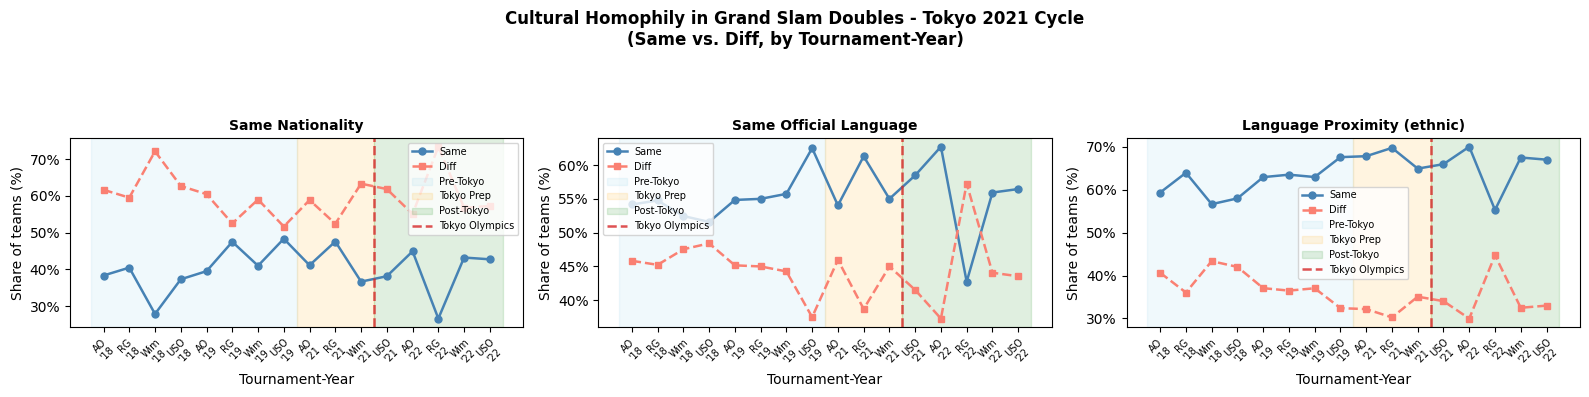

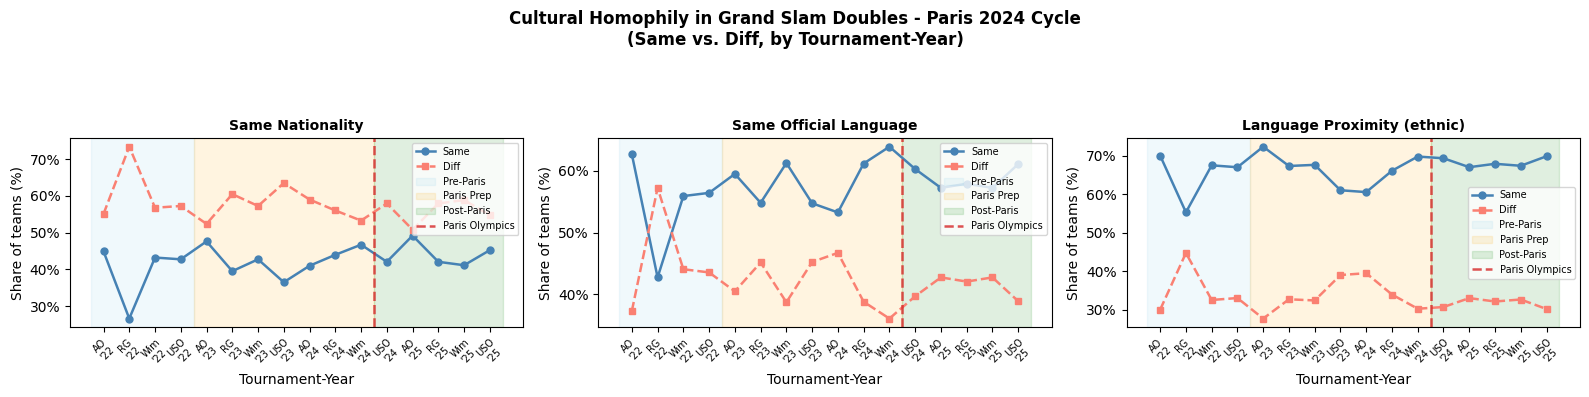

In [11]:
TOURN_ORDER = {'Australian Open': 0, 'Roland Garros': 1, 'Wimbledon': 2, 'US Open': 3}
TOURN_ABBR  = {'Australian Open': 'AO', 'Roland Garros': 'RG', 'Wimbledon': 'Wim', 'US Open': 'USO'}

avg_cols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']
titles   = ['Same Nationality', 'Same Official Language', 'Language Proximity (ethnic)']

# Chronologically-ordered tournament-year means
ty = gs.groupby(['year', 'tournament'])[avg_cols].mean().mul(100).reset_index()
ty['t_order'] = ty['tournament'].map(TOURN_ORDER)
ty = ty.sort_values(['year', 't_order']).reset_index(drop=True)
ty['label'] = ty.apply(lambda r: f"{TOURN_ABBR[r['tournament']]}\n'{str(r['year'])[2:]}", axis=1)

# ── Tokyo cycle ───────────────────────────────────────────────────────────
ty_t = ty[ty['year'].isin([2018, 2019, 2021, 2022])].reset_index(drop=True)
ty_t['x'] = ty_t.index

pre_t  = ty_t['year'].isin([2018, 2019])
prep_t = (ty_t['year'] == 2021) & ty_t['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon'])
post_t = ((ty_t['year'] == 2021) & (ty_t['tournament'] == 'US Open')) | (ty_t['year'] == 2022)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_t['x'], ty_t[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_t['x'], 100-ty_t[ac],   marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')
    for mask, color, lbl in [(pre_t, 'skyblue', 'Pre-Tokyo'), (prep_t, 'orange', 'Tokyo Prep'), (post_t, 'green', 'Post-Tokyo')]:
        xs = ty_t.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=0.12, color=color, label=lbl)
    x_wim = ty_t.loc[(ty_t['year'] == 2021) & (ty_t['tournament'] == 'Wimbledon'), 'x']
    x_uso = ty_t.loc[(ty_t['year'] == 2021) & (ty_t['tournament'] == 'US Open'),   'x']
    if not x_wim.empty and not x_uso.empty:
        ax.axvline((x_wim.values[0] + x_uso.values[0]) / 2,
                   color='#d62728', ls='--', lw=1.8, alpha=0.8, label='Tokyo Olympics')
    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year'); ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_t['x']); ax.set_xticklabels(ty_t['label'], fontsize=7)
    ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=7)

fig.suptitle('Cultural Homophily in Grand Slam Doubles - Tokyo 2021 Cycle\n(Same vs. Diff, by Tournament-Year)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_tokyo_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Paris cycle ───────────────────────────────────────────────────────────
ty_p = ty[ty['year'].isin([2022, 2023, 2024, 2025])].reset_index(drop=True)
ty_p['x'] = ty_p.index

pre_p  = ty_p['year'] == 2022
prep_p = (ty_p['year'] == 2023) | ((ty_p['year'] == 2024) & ty_p['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon']))
post_p = ((ty_p['year'] == 2024) & (ty_p['tournament'] == 'US Open')) | (ty_p['year'] == 2025)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_p['x'], ty_p[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_p['x'], 100-ty_p[ac],   marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')
    for mask, color, lbl in [(pre_p, 'skyblue', 'Pre-Paris'), (prep_p, 'orange', 'Paris Prep'), (post_p, 'green', 'Post-Paris')]:
        xs = ty_p.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=0.12, color=color, label=lbl)
    x_wim = ty_p.loc[(ty_p['year'] == 2024) & (ty_p['tournament'] == 'Wimbledon'), 'x']
    x_uso = ty_p.loc[(ty_p['year'] == 2024) & (ty_p['tournament'] == 'US Open'),   'x']
    if not x_wim.empty and not x_uso.empty:
        ax.axvline((x_wim.values[0] + x_uso.values[0]) / 2,
                   color='#d62728', ls='--', lw=1.8, alpha=0.8, label='Paris Olympics')
    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year'); ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_p['x']); ax.set_xticklabels(ty_p['label'], fontsize=7)
    ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=7)

fig.suptitle('Cultural Homophily in Grand Slam Doubles - Paris 2024 Cycle\n(Same vs. Diff, by Tournament-Year)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_paris_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

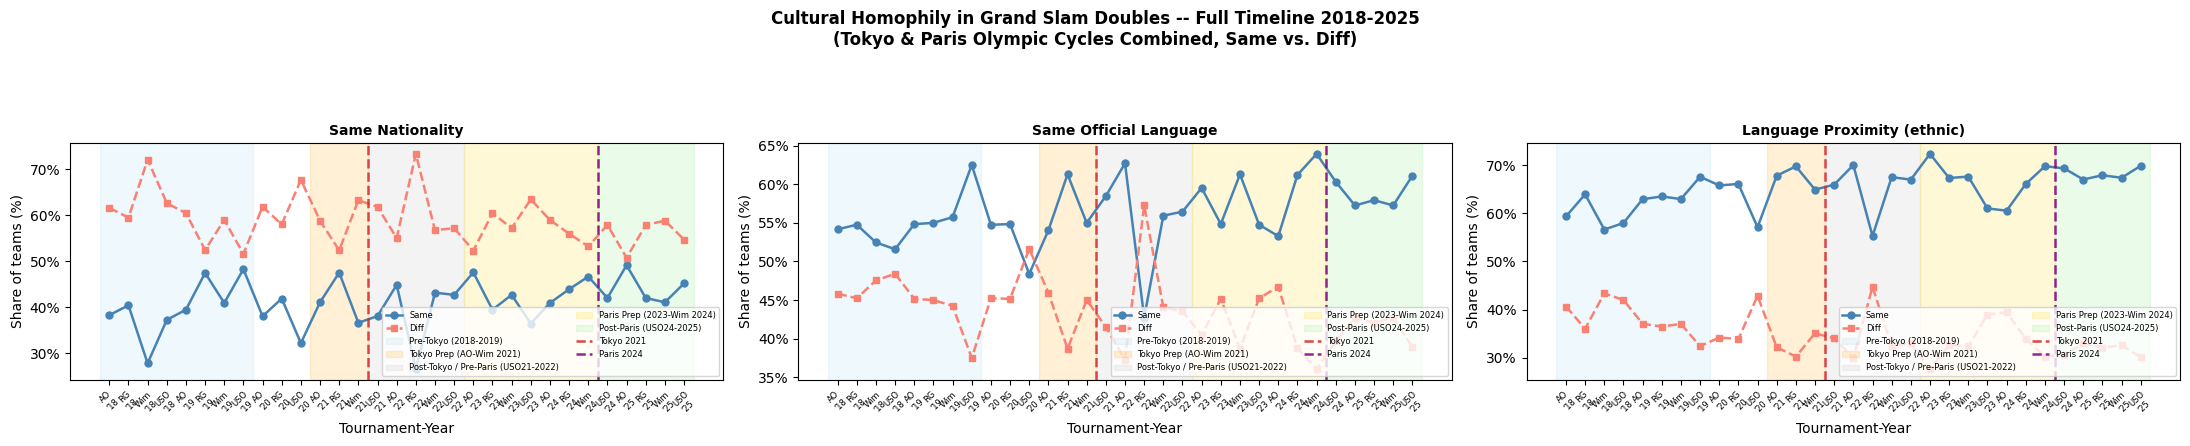

In [12]:
# Combined Tokyo + Paris cycle graph (full timeline 2018-2025)
# Single figure spanning all Grand Slams in the dataset (Olympics excluded).
# Two vertical lines mark the Olympic tournaments; shaded bands show each period.

ty_full = ty.copy()
ty_full['x'] = ty_full.index   # ty already sorted chronologically

mask_pre_tokyo  = ty_full['year'].isin([2018, 2019])
mask_tokyo_prep = (ty_full['year'] == 2021) & ty_full['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon'])
mask_interlude  = ((ty_full['year'] == 2021) & (ty_full['tournament'] == 'US Open')) | (ty_full['year'] == 2022)
mask_paris_prep = (ty_full['year'] == 2023) | ((ty_full['year'] == 2024) & ty_full['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon']))
mask_post_paris = ((ty_full['year'] == 2024) & (ty_full['tournament'] == 'US Open')) | (ty_full['year'] == 2025)

x_wim21 = ty_full.loc[(ty_full['year'] == 2021) & (ty_full['tournament'] == 'Wimbledon'), 'x'].values
x_uso21 = ty_full.loc[(ty_full['year'] == 2021) & (ty_full['tournament'] == 'US Open'),   'x'].values
x_wim24 = ty_full.loc[(ty_full['year'] == 2024) & (ty_full['tournament'] == 'Wimbledon'), 'x'].values
x_uso24 = ty_full.loc[(ty_full['year'] == 2024) & (ty_full['tournament'] == 'US Open'),   'x'].values

fig, axes = plt.subplots(1, 3, figsize=(22, 4.5), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_full['x'], ty_full[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_full['x'], 100 - ty_full[ac], marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')

    shades = [
        (mask_pre_tokyo,  'skyblue',    0.13, 'Pre-Tokyo (2018-2019)'),
        (mask_tokyo_prep, 'orange',     0.16, 'Tokyo Prep (AO-Wim 2021)'),
        (mask_interlude,  'lightgray',  0.25, 'Post-Tokyo / Pre-Paris (USO21-2022)'),
        (mask_paris_prep, 'gold',       0.16, 'Paris Prep (2023-Wim 2024)'),
        (mask_post_paris, 'lightgreen', 0.18, 'Post-Paris (USO24-2025)'),
    ]
    for mask, color, alpha, lbl in shades:
        xs = ty_full.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=alpha, color=color, label=lbl)

    if len(x_wim21) and len(x_uso21):
        ax.axvline((x_wim21[0] + x_uso21[0]) / 2, color='#d62728', ls='--', lw=1.8, alpha=0.85, label='Tokyo 2021')
    if len(x_wim24) and len(x_uso24):
        ax.axvline((x_wim24[0] + x_uso24[0]) / 2, color='purple',  ls='--', lw=1.8, alpha=0.85, label='Paris 2024')

    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year')
    ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_full['x'])
    ax.set_xticklabels(ty_full['label'], fontsize=6)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=6, ncol=2, loc='lower right')

fig.suptitle('Cultural Homophily in Grand Slam Doubles -- Full Timeline 2018-2025\n'
             '(Tokyo & Paris Olympic Cycles Combined, Same vs. Diff)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_combined_cycles.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Team Panel Construction

Convert match-level data to team-level panel: each match creates 2 observations (winners=1, losers=0).


In [13]:
# Build team panel (match-level to team-level: winners row + losers row)
match_vars = ['match_id','tournament','year','surface','stage_code','any_tb','any_std_tb','regular_tb','match_tb',
              'match_tb_set','tb_s3_regular','tb_s4','tb_s5',
              'three_sets','comeback','winner_lost_s1','pre_olympic','olympic_period','olympics_tourn']

# Winners row
w_row = df[match_vars].copy()
for col, src in [('same_country','same_country_winners'),('same_language','winners_same_language'),
                 ('ling_prox','winners_ling_prox_cont'),('rank_mean','rank_mean_winners'),
                 ('wl_career_diff','wl_career_diff_winners'),('rank_gap','rank_diff_winners'),
                 ('ling_prox_binary','winners_linguistic_proximity'),
                 ('ling_prox_psw_tree','winners_ling_prox_psw_tree'),
                 ('ling_prox_psw_cognet','winners_ling_prox_psw_cognet')]:
    w_row[col] = df[src].values
w_row['single_top100'] = ((df['winners_p1_top100_within_1y']==1) | (df['winners_p2_top100_within_1y']==1)).astype(int)
w_row['win'] = 1
w_row['won_tb_s1'] = df['w_won_tb_s1'].values
w_row['won_tb_s2'] = df['w_won_tb_s2'].values
# won_tb_s3/s4/s5: who won that *specific set's* tiebreak, read directly off that
# set's own score column. This is deliberately NOT inferred from the match winner
# (df['win']), because for a best-of-5 match set 3 (or 4) need not be the deciding
# set -- the match winner can lose an individual set's tiebreak along the way.
w_row['won_tb_s3'] = df['w_won_tb_s3'].values
w_row['won_tb_s4'] = df['w_won_tb_s4'].values
w_row['won_tb_s5'] = df['w_won_tb_s5'].values

# Losers row
l_row = df[match_vars].copy()
for col, src in [('same_country','same_country_losers'),('same_language','losers_same_language'),
                 ('ling_prox','losers_ling_prox_cont'),('rank_mean','rank_mean_losers'),
                 ('wl_career_diff','wl_career_diff_losers'),('rank_gap','rank_diff_losers'),
                 ('ling_prox_binary','losers_linguistic_proximity'),
                 ('ling_prox_psw_tree','losers_ling_prox_psw_tree'),
                 ('ling_prox_psw_cognet','losers_ling_prox_psw_cognet')]:
    l_row[col] = df[src].values
l_row['single_top100'] = ((df['losers_p1_top100_within_1y']==1) | (df['losers_p2_top100_within_1y']==1)).astype(int)
l_row['win'] = 0
l_row['won_tb_s1'] = (df['tb_s1'] & (df['winners_set1']==6)).values
l_row['won_tb_s2'] = (df['tb_s2'] & (df['winners_set2']==6)).values
l_row['won_tb_s3'] = (df['tb_s3_regular'] & (df['winners_set3']==6)).values
l_row['won_tb_s4'] = (df['tb_s4'] & (df['winners_set4']==6)).values
l_row['won_tb_s5'] = (df['tb_s5'] & (df['winners_set5']==6)).values

# Team-level experience: avg years since turning pro across both players (values <=0 treated as NaN)
for _row, _p1c, _p2c in [
    (w_row, 'winners_p1_experience_double', 'winners_p2_experience_double'),
    (l_row, 'losers_p1_experience_double',  'losers_p2_experience_double'),
]:
    _e1 = df[_p1c].where(df[_p1c] > 0).values.astype(float)
    _e2 = df[_p2c].where(df[_p2c] > 0).values.astype(float)
    with np.errstate(all='ignore'):
        _exp = np.nanmean(np.column_stack([_e1, _e2]), axis=1)
    _exp[np.isnan(_e1) & np.isnan(_e2)] = np.nan
    _row['exp_mean'] = _exp

# Concatenate and compute derived variables

# Team-level age at tournament: avg age (tournament year - birth year) across both
# players, mirroring the exp_mean block above exactly (same NaN-tolerant averaging).
for _row, _p1c, _p2c in [
    (w_row, 'winners_p1_dob_dt', 'winners_p2_dob_dt'),
    (l_row, 'losers_p1_dob_dt',  'losers_p2_dob_dt'),
]:
    _a1 = (df['year'] - df[_p1c].dt.year).values.astype(float)
    _a2 = (df['year'] - df[_p2c].dt.year).values.astype(float)
    with np.errstate(all='ignore'):
        _age = np.nanmean(np.column_stack([_a1, _a2]), axis=1)
    _age[np.isnan(_a1) & np.isnan(_a2)] = np.nan
    _row['age_mean'] = _age

team_df = pd.concat([w_row, l_row], ignore_index=True)
team_df['opp_rank_mean'] = team_df.groupby('match_id')['rank_mean'].transform('sum') - team_df['rank_mean']
team_df['stage_code'] = team_df['stage_code'].fillna(-1).astype(int)
team_df['lost_set1'] = np.where(team_df['win']==1, team_df['winner_lost_s1'], ~team_df['winner_lost_s1'])
team_df['comeback'] = (team_df['win'] & team_df['lost_set1']).astype(int)

# Convert booleans to int
for col in team_df.columns:
    if str(team_df[col].dtype) in ('bool','boolean','Int64','Int32'):
        team_df[col] = team_df[col].fillna(0).astype(int)

# Drop entire matches with incomplete ranking or nationality data
bad_rank = set(team_df.loc[team_df['rank_mean'].isna(), 'match_id'])
bad_nat  = set(
    team_df.loc[team_df[['same_country','same_language','ling_prox']].isna().any(axis=1), 'match_id']
)
bad_matches = bad_rank | bad_nat
n_rank = len(bad_rank)
n_nat  = len(bad_nat - bad_rank)

team_df = team_df[~team_df['match_id'].isin(bad_matches)].reset_index(drop=True)

print(f'Team panel constructed: {len(team_df):,} obs | {team_df["match_id"].nunique():,} matches')
print(f'  Dropped {n_rank} matches: ranking incomplete (both players on one team unranked)')
print(f'  Dropped {n_nat} matches: nationality/language data missing for at least one player')
print(f'  Total matches dropped: {len(bad_matches)}')
print(f'  exp_mean coverage: {team_df["exp_mean"].notna().sum():,} / {len(team_df):,} obs ({100*team_df["exp_mean"].notna().mean():.1f}%)')


# Combined tournament-year key so Patsy only dummies cells that exist in the data
team_df['tourn_year'] = team_df['tournament'].astype(str) + '_' + team_df['year'].astype(str)

Team panel constructed: 3,854 obs | 1,927 matches
  Dropped 10 matches: ranking incomplete (both players on one team unranked)
  Dropped 0 matches: nationality/language data missing for at least one player
  Total matches dropped: 10
  exp_mean coverage: 3,641 / 3,854 obs (94.5%)


## 4. Baseline Regressions

Each match contributes **two** observations (winner team = 1, loser team = 0).  
Each culture measure (`same_country`, `same_language`, `ling_prox`) is entered one at a time.  
Controls: team average doubles ranking, opponent ranking, teammate rank gap, top-100 singles indicator.  
Fixed effects: tournament-by-year interaction, round (stage_code).  
Standard errors clustered by match.

In [14]:
# Grand Slams panel (Olympics excluded)
# Cell 14 already dropped incomplete-ranking and incomplete-nationality matches from team_df
team_gs = team_df[team_df['olympics_tourn'] == 0].dropna(subset=['rank_mean', 'rank_gap']).copy()
team_gs['won_regular_tb'] = ((team_gs['won_tb_s1'] == 1) | (team_gs['won_tb_s2'] == 1)).astype(int)
team_gs['won_any_tb'] = ((team_gs['won_tb_s1'] == 1) | (team_gs['won_tb_s2'] == 1) |
                         (team_gs['match_tb'] == 1) | (team_gs['tb_s3_regular'] == 1)).astype(int)

# exp_mean = tournament_year - year_turned_pro (professional tenure in years), averaged
# across the two teammates. Impute to 1 for rookies (turned pro in or after the
# tournament year, so raw tenure is <= 0 and was set to NaN upstream) -- a nominal
# first-year tenure rather than zero, per review feedback; no observations are dropped.
team_gs['exp_mean'] = team_gs['exp_mean'].fillna(1)
team_gs['exp_mean_sq'] = team_gs['exp_mean'] ** 2
# Demean exp_mean (used in place of the raw variable everywhere below) and build its
# square from the demeaned variable, so 'years since turning pro' AMEs are evaluated at
# mean tenure, not at zero tenure, in every table (Table 3/4/5/6/6a).
team_gs['exp_mean_dm'] = team_gs['exp_mean'] - team_gs['exp_mean'].mean()
team_gs['exp_mean_dm_sq'] = team_gs['exp_mean_dm'] ** 2
# Team-level age at tournament, demeaned against this estimation sample's own mean,
# mirroring exp_mean_dm. No rookie-style imputation is needed for age: dob coverage is
# complete for every team-obs that survives the ranking/nationality filters above.
team_gs['age_mean_dm'] = team_gs['age_mean'] - team_gs['age_mean'].mean()
team_gs['age_mean_dm_sq'] = team_gs['age_mean_dm'] ** 2
print(f'  age_mean coverage: {team_gs["age_mean"].notna().sum():,} / {len(team_gs):,} obs ({100*team_gs["age_mean"].notna().mean():.1f}%)')
gs_matches = team_gs['match_id'].nunique()
mc = team_gs.groupby('match_id').size()
print(f'Team panel (Grand Slams only): {len(team_gs):,} obs | {gs_matches:,} unique matches')
print(f'  Complete pairs (2 obs): {(mc==2).sum():,}  |  Singleton obs (rank or nat/lang incomplete): {(mc==1).sum():,}')

# Panel including Olympics
team_all = team_df.dropna(subset=['rank_mean', 'rank_gap']).copy()
team_all['won_regular_tb'] = ((team_all['won_tb_s1'] == 1) | (team_all['won_tb_s2'] == 1)).astype(int)
team_all['won_any_tb'] = ((team_all['won_tb_s1'] == 1) | (team_all['won_tb_s2'] == 1) |
                          (team_all['match_tb'] == 1) | (team_all['tb_s3_regular'] == 1)).astype(int)
team_all['exp_mean'] = team_all['exp_mean'].fillna(1)
team_all['exp_mean_sq'] = team_all['exp_mean'] ** 2
team_all['age_mean_dm'] = team_all['age_mean'] - team_all['age_mean'].mean()
team_all['age_mean_dm_sq'] = team_all['age_mean_dm'] ** 2
print(f'Team panel (incl. Olympics):   {len(team_all):,} obs | {team_all["match_id"].nunique():,} unique matches')

  age_mean coverage: 3,728 / 3,728 obs (100.0%)
Team panel (Grand Slams only): 3,728 obs | 1,864 unique matches
  Complete pairs (2 obs): 1,864  |  Singleton obs (rank or nat/lang incomplete): 0
Team panel (incl. Olympics):   3,854 obs | 1,927 unique matches


In [15]:
output_gs  = f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/team_gs_panel.csv"
output_all = f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/team_all_panel.csv"

# Compute ic_team before saving so the CSV always includes Hofstede columns.
# Cell 30 will re-use these for the in-memory team_gs (same calculation).
_hof_path   = f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/gravity/hofstede.csv"
_excel_path = f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx"
_idv_map = pd.read_csv(_hof_path, usecols=["iso3","idv"]).dropna().set_index("iso3")["idv"].to_dict()
_iso_cols = ["match_id","winners_p1_iso3","winners_p2_iso3","losers_p1_iso3","losers_p2_iso3"]
_raw = pd.read_excel(_excel_path, sheet_name="players_list", usecols=_iso_cols)
def _lu(iso):
    if pd.isna(iso): return float("nan")
    return _idv_map.get(str(iso), float("nan"))
_raw["ic_w"] = (_raw["winners_p1_iso3"].apply(_lu) + _raw["winners_p2_iso3"].apply(_lu)) / 2
_raw["ic_l"] = (_raw["losers_p1_iso3"].apply(_lu)  + _raw["losers_p2_iso3"].apply(_lu))  / 2
_match_ic = _raw[["match_id","ic_w","ic_l"]].copy()

_gs_save = team_gs.drop(columns=["ic_team","ic_team_dm"], errors="ignore").merge(_match_ic, on="match_id", how="left")
_gs_save["ic_team"] = _gs_save.apply(lambda r: r["ic_w"] if r["win"]==1 else r["ic_l"], axis=1)
_gs_save = _gs_save.drop(columns=["ic_w","ic_l"])
_ic_mean = _gs_save["ic_team"].mean()
_gs_save["ic_team_dm"] = _gs_save["ic_team"] - _ic_mean
_gs_save.to_csv(output_gs, index=False)
team_all.to_csv(output_all, index=False)
print(f"Grand Slams panel saved to {output_gs} (includes ic_team_dm)")
print(f"Full panel (incl. Olympics) saved to {output_all}")


Grand Slams panel saved to C:/Users/aldi/Documents/GitHub/tennis-homophily/data/atp/team_gs_panel.csv (includes ic_team_dm)
Full panel (incl. Olympics) saved to C:/Users/aldi/Documents/GitHub/tennis-homophily/data/atp/team_all_panel.csv


### 2.4 Where 1,876 and 1,886 Come From

All descriptive stats above (section 2, 2.1-2.3) are computed on the exact 1,876-match
regression sample, so they already reconcile with Tables 3-6 by construction. This
section explains how that 1,876 relates to the raw data and the 48 dropped
retirements/walkovers, and confirms a fix applied to the retirement filter.

- **1,997** raw scraped matches (Grand Slams + Olympics).
- Drop **48** retirements/walkovers (flagged from incomplete/invalid set scores) -> **1,949**
  matches remain (Grand Slams + Olympics). 47 of those 48 were Grand Slam matches; only 1
  was an Olympic match.
- Of the 1,949, **63 are Olympic matches** (Tokyo 2021 + Paris 2024) and **1,886 are
  Grand Slam matches** -- this is where **1,886** comes from: Grand Slam matches after
  dropping retirements/walkovers, but *before* the ranking- and nationality-completeness
  filters below. It is not used as the base for section 2/2.1/2.2/2.3 above (those use
  1,876), but it is the natural intermediate count when tracing the funnel.
- From the 1,886, a further **10** matches are dropped for incomplete doubles ranking
  data (0 more for nationality/language, which the pipeline fully resolves) ->
  **1,876** Grand Slam matches: the final regression sample, matching
  `team_gs_panel.csv` exactly. (Of the 14 originally ranking-incomplete matches, 4 were
  retrieved and restored: 3 -- match_id 6, 35, 49 -- failed only on an accented-surname
  merge mismatch for Guillermo Garcia-Lopez; 1 -- match_id 913, 2021 Wimbledon -- had a
  genuinely blank partner slot for Alejandro Davidovich Fokina, whose profile was
  reconstructed from public sources. The remaining 10 could not be reliably retrieved.)

**Fix applied to the retirement filter** (previously flagged as a known, unfixed gap):
the completeness check only inspected sets 1-3, and only recognized a 2-game-margin
finish (e.g. 8-6) as valid -- not a 1-game-margin breaker finish (e.g. 13-12). Two
Wimbledon 2021 matches (`match_id` 903, 927) that legitimately finished 13-12 in the
third set were misread as incomplete and wrongly excluded; two other matches with a
genuine retirement in the *4th* set -- Wimbledon 2019 (`match_id` 504, retired at 4-3)
and Wimbledon 2022 (`match_id` 1204, retired at 1-1) -- were invisible to a filter that
never looked past set 3, and were wrongly included. Both issues are now fixed: the
completeness check recognizes the 12-12-breaker pattern as valid, and sets 4-5 are now
also checked when present. Net effect on the 1,876 count is a wash (2 matches swapped
for 2 others), but the sample now contains the *correct* 2 in each direction. The
`match_tb` threshold was also widened from `hi>=10` to `hi>=8`, since genuine long
advantage-set finishes like 8-6 or 9-7 were being missed by the old threshold (7 such
matches added: 4 at set 3, 3 at set 5).


In [16]:
import os as _os2
_root2 = _os2.path.abspath(_os2.path.join(_os2.getcwd(), '..', '..'))
_tg = pd.read_csv(_os2.path.join(_root2, 'data', 'atp', 'team_gs_panel.csv'))
_tb = pd.read_csv(_os2.path.join(_root2, 'data', 'atp', 'tiebreak_panel.csv'))

print('=== 2.4 Reconciliation Check ===')
print()
print(f'df_gs_desc (regression sample, matches section 2 above): {len(df_gs_desc):,} matches')
print(f'team_gs_panel.csv (Table 3 sample):                      {_tg["match_id"].nunique():,} matches | {len(_tg):,} team-obs')
print(f'tiebreak_panel.csv (Table 4 sample, sets 1-5):           {len(_tb)//2:,} tiebreaks | {len(_tb):,} team-obs')
print()

print('Retirement-filter fix confirmation:')
_flag_cases = [
    (903,  '2021 Wimbledon', '13-12 in set 3 (valid 12-12-breaker finish)', True),
    (927,  '2021 Wimbledon', '13-12 in set 3 (valid 12-12-breaker finish)', True),
    (504,  '2019 Wimbledon', '4-3 in set 4 (incomplete -- retirement)',     False),
    (1204, '2022 Wimbledon', '1-1 in set 4 (incomplete -- retirement)',     False),
]
for mid, where, why, should_be_present in _flag_cases:
    present = mid in set(_tg['match_id'])
    status = 'OK' if present == should_be_present else 'MISMATCH'
    print(f'  match_id {mid:5d}  {where:16s}  {why:45s}  present={present}  expected={should_be_present}  [{status}]')


=== 2.4 Reconciliation Check ===

df_gs_desc (regression sample, matches section 2 above): 1,864 matches
team_gs_panel.csv (Table 3 sample):                      1,864 matches | 3,728 team-obs
tiebreak_panel.csv (Table 4 sample, sets 1-5):           1,177 tiebreaks | 2,354 team-obs

Retirement-filter fix confirmation:
  match_id   903  2021 Wimbledon    13-12 in set 3 (valid 12-12-breaker finish)    present=True  expected=True  [OK]
  match_id   927  2021 Wimbledon    13-12 in set 3 (valid 12-12-breaker finish)    present=True  expected=True  [OK]
  match_id   504  2019 Wimbledon    4-3 in set 4 (incomplete -- retirement)        present=False  expected=False  [OK]
  match_id  1204  2022 Wimbledon    1-1 in set 4 (incomplete -- retirement)        present=False  expected=False  [OK]


### 2.5 Olympics: Pressure Outcome Counts

The main pressure-outcome summary above (section 2, 2.1, 2.2) excludes the Olympics, to
keep the headline descriptive statistics aligned with the Grand-Slams-only regression
sample. Olympic tennis follows different rules in this dataset (no genuine Grand Slam
tournament structure, and its own deciding-set conventions), so it is reported here
separately rather than pooled into the main counts.


In [17]:
df_oly = df[df['olympics_tourn'] == 1]
print(f'=== Olympics Pressure Outcome Counts (N={len(df_oly):,} matches: Tokyo 2021 + Paris 2024) ===')
rows = [
    ('Set-1 tiebreak (7-pt)',                 df_oly['tb_s1']),
    ('Set-2 tiebreak (7-pt)',                 df_oly['tb_s2']),
    ('Set-3 regular tiebreak (7-pt)',         df_oly['tb_s3_regular']),
    ('Advantage-set / 12-12-breaker decider', df_oly['match_tb']),
    ('Any regular tiebreak (sets 1 or 2)',    df_oly['regular_tb']),
    ('Any tiebreak (all types)',              df_oly['any_tb']),
    ('Match went to 3 sets',                  df_oly['three_sets']),
    ('Comeback wins (winner lost set 1)',     df_oly['comeback']),
]
for lbl, s in rows:
    print(f'  {lbl:<50s}  N={int(s.sum()):4d}  ({100*s.mean():.1f}%)')

print()
print('By Olympic year:')
print(df_oly.groupby('year').size().rename('n_matches').to_string())
print()
print('Advantage-set / 12-12-breaker deciders by year:')
print(df_oly[df_oly['match_tb']].groupby('year').size().to_frame('N').to_string())

# Olympics never records a 4th set in this dataset -- best-of-3 throughout.
_oly_bo5 = df_oly['winners_set4'].notna().sum()
print()
print(f'Matches reaching a 4th set: {_oly_bo5} (Olympics is best-of-3 throughout).')


=== Olympics Pressure Outcome Counts (N=63 matches: Tokyo 2021 + Paris 2024) ===
  Set-1 tiebreak (7-pt)                               N=  12  (19.0%)
  Set-2 tiebreak (7-pt)                               N=  21  (33.3%)
  Set-3 regular tiebreak (7-pt)                       N=   0  (0.0%)
  Advantage-set / 12-12-breaker decider               N=  20  (31.7%)
  Any regular tiebreak (sets 1 or 2)                  N=  28  (44.4%)
  Any tiebreak (all types)                            N=  33  (52.4%)
  Match went to 3 sets                                N=  20  (31.7%)
  Comeback wins (winner lost set 1)                   N=  13  (20.6%)

By Olympic year:
year
2021    31
2024    32

Advantage-set / 12-12-breaker deciders by year:
       N
year    
2021   9
2024  11

Matches reaching a 4th set: 0 (Olympics is best-of-3 throughout).


In [18]:
FE = '+ C(tourn_year) + C(stage_code)'

CULTURE_VARS = [
    ('same_country',  'Same nationality'),
    ('same_language', 'Same official language'),
    ('ling_prox',     'Language proximity (prox1)'),
]

CONTROLS = 'rank_mean + opp_rank_mean + single_top100 + exp_mean_dm + exp_mean_dm_sq'

ctrl_vars = [
    ('rank_mean',      'Team avg doubles ranking'),
    ('opp_rank_mean',  'Opponent avg doubles ranking'),
    ('single_top100',  'Top-100 singles player'),
    ('exp_mean_dm',    'Team avg. yrs since turning pro'),
    ('exp_mean_dm_sq', 'Yrs since turning pro, squared'),
]
CONTROLS_RG = CONTROLS + ' + rank_gap'
rg_ctrl_vars = ctrl_vars + [('rank_gap', 'Teammate rank gap')]

def show_vars(res, var_list, prefix=''):
    for v, lbl in var_list:
        if v not in res.params:
            continue
        c, se, p = res.params[v], res.bse[v], res.pvalues[v]
        stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
        print(f'  {prefix}{lbl:<42s}  {c:+.4f}{stars:<3s}  se={se:.4f}  p={p:.3f}')
ALL_CTRL_VARS = [
    ('rank_mean',      'Team avg. doubles ranking'),
    ('opp_rank_mean',  'Opponent avg. doubles ranking'),
    ('single_top100',  'Top-100 singles player'),
    ('exp_mean_dm',    'Team avg. yrs since turning pro'),
    ('exp_mean_dm_sq', 'Yrs since turning pro, squared'),
]

def show_ames(me, var_list):
    sf_idx = list(me.summary_frame().index)
    def star(p): return '***' if p<.01 else '**' if p<.05 else '*' if p<.1 else ''
    for v, lbl in var_list:
        if v not in sf_idx: continue
        i = sf_idx.index(v)
        ame, se, p = me.margeff[i], me.margeff_se[i], me.pvalues[i]
        print(f'  {lbl:<42s}  {ame:+.4f}{star(p):<3s}  se=({se:.4f})  p={p:.3f}')


In [19]:
print('=== Table 3. Match Win -- Logit ===')
print('AME (dP/dx). FE: tournament x year + round | SE clustered by match | Sample: Grand Slams only')
print(f'N: {len(team_gs):,} obs | {team_gs["match_id"].nunique():,} unique matches')
print()

for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {CONTROLS} {FE}', data=team_gs).fit(
        cov_type='cluster', cov_kwds={'groups': team_gs['match_id']}, disp=False)
    me = res.get_margeff()
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_ames(me, [(cvar, clbl)] + ALL_CTRL_VARS)
    print()


=== Table 3. Match Win -- Logit ===
AME (dP/dx). FE: tournament x year + round | SE clustered by match | Sample: Grand Slams only
N: 3,728 obs | 1,864 unique matches



  [Same nationality]  N=3,728  Pseudo-R2=0.096


  Same nationality                            +0.0361**   se=(0.0164)  p=0.028
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0042     se=(0.0315)  p=0.894
  Team avg. yrs since turning pro             +0.0044***  se=(0.0017)  p=0.008
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001



  [Same official language]  N=3,728  Pseudo-R2=0.097
  Same official language                      +0.0420***  se=(0.0157)  p=0.007
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0032     se=(0.0315)  p=0.920
  Team avg. yrs since turning pro             +0.0042**   se=(0.0017)  p=0.011
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001



  [Language proximity (prox1)]  N=3,728  Pseudo-R2=0.096
  Language proximity (prox1)                  +0.0501**   se=(0.0202)  p=0.013
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0031     se=(0.0314)  p=0.920
  Team avg. yrs since turning pro             +0.0043***  se=(0.0017)  p=0.010
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001



In [20]:
print('=== Appendix Table A3. Match Win -- Language Proximity Robustness ===')
print('Same spec as Table 3 (logit AME, FE: tournament x year + round, SE clustered by match).')
print('Main text (Table 3, col 3) uses ling_prox = prox1 (continuous, Melitz & Toubal 2014 --')
print('the same source Bekes & Ottaviano 2025 use). This appendix table shows the three')
print('alternative measures relocated out of the main text on 2026-09-10:')
print('  binary   -- CEPII comlang_ethno (the original main-text measure)')
print('  psw_tree -- PSW2024 (geopoliticaldistance.org), inverted tree distance')
print('  psw_cognet -- PSW2024, cognate/lexical-based proximity')
print(f'N: {len(team_gs):,} obs | {team_gs["match_id"].nunique():,} unique matches')
print()

APPENDIX_A3_VARS = [
    ('ling_prox_binary',   'Ling. proximity (binary, comlang_ethno)'),
    ('ling_prox_psw_tree', 'Ling. proximity (PSW tree, continuous)'),
    ('ling_prox_psw_cognet', 'Ling. proximity (PSW cognet, continuous)'),
]

for cvar, clbl in APPENDIX_A3_VARS:
    _sub = team_gs.dropna(subset=[cvar])
    res = smf.logit(f'win ~ {cvar} + {CONTROLS} {FE}', data=_sub).fit(
        cov_type='cluster', cov_kwds={'groups': _sub['match_id']}, disp=False, maxiter=200)
    me = res.get_margeff()
    sf = me.summary_frame()
    row = sf.loc[cvar]
    sd = _sub[cvar].std()
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}  (SD of {cvar}={sd:.3f})')
    show_ames(me, [(cvar, clbl)] + ALL_CTRL_VARS)
    stars = '***' if row['Pr(>|z|)']<.01 else '**' if row['Pr(>|z|)']<.05 else '*' if row['Pr(>|z|)']<.1 else ''
    print(f'    per-SD AME (n/a for binary): {row["dy/dx"]*sd:+.4f}{stars}')
    print()


=== Appendix Table A3. Match Win -- Language Proximity Robustness ===
Same spec as Table 3 (logit AME, FE: tournament x year + round, SE clustered by match).
Main text (Table 3, col 3) uses ling_prox = prox1 (continuous, Melitz & Toubal 2014 --
the same source Bekes & Ottaviano 2025 use). This appendix table shows the three
alternative measures relocated out of the main text on 2026-09-10:
  binary   -- CEPII comlang_ethno (the original main-text measure)
  psw_tree -- PSW2024 (geopoliticaldistance.org), inverted tree distance
  psw_cognet -- PSW2024, cognate/lexical-based proximity
N: 3,728 obs | 1,864 unique matches



  [Ling. proximity (binary, comlang_ethno)]  N=3,728  Pseudo-R2=0.096  (SD of ling_prox_binary=0.495)
  Ling. proximity (binary, comlang_ethno)     +0.0380**   se=(0.0157)  p=0.015
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0026     se=(0.0315)  p=0.935
  Team avg. yrs since turning pro             +0.0042**   se=(0.0017)  p=0.012
  Yrs since turning pro, squared              -0.0007***  se=(0.0002)  p=0.001
    per-SD AME (n/a for binary): +0.0188**



  [Ling. proximity (PSW tree, continuous)]  N=3,728  Pseudo-R2=0.097  (SD of ling_prox_psw_tree=0.348)
  Ling. proximity (PSW tree, continuous)      +0.0648***  se=(0.0231)  p=0.005
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0038     se=(0.0314)  p=0.905
  Team avg. yrs since turning pro             +0.0046***  se=(0.0017)  p=0.006
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001
    per-SD AME (n/a for binary): +0.0225***



  [Ling. proximity (PSW cognet, continuous)]  N=3,728  Pseudo-R2=0.097  (SD of ling_prox_psw_cognet=0.346)
  Ling. proximity (PSW cognet, continuous)    +0.0719***  se=(0.0231)  p=0.002
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0034     se=(0.0315)  p=0.914
  Team avg. yrs since turning pro             +0.0047***  se=(0.0017)  p=0.005
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001
    per-SD AME (n/a for binary): +0.0249***



## 4a-0. Robustness: Disentangling Nationality from Language

Per Lingqing's request (2026-09-02): the main same_country / same_language indicators are
correlated (all same_country=1 team-obs also have same_language=1 in this sample -- no
same-nationality/different-language teams exist), so Table 3 alone cannot tell whether the
cultural-similarity result is driven by shared nationality specifically or by shared
language more broadly. We define three mutually exclusive categories that partition the
full GS sample:

- **same_nat_same_lang**: same nationality (implies same language in this data)
- **diff_nat_same_lang**: different nationality, same official language (e.g. Germany/Austria,
  UK/Australia/US, Spain/Argentina)
- **diff_nat_diff_lang**: different nationality, different language (omitted reference category)

**Updated 2026-09-17 (per user request for report clarity):** rather than one joint
regression with both dummies entered together, each category is now tested in its own
separate logit spec, one dummy at a time (same controls/FE/clustering as Table 3), against
the full remaining sample -- mirroring how Table 3 itself enters same_country/same_language/
ling_prox one at a time rather than jointly. The key question is whether diff_nat_same_lang
still shows a positive performance association net of controls -- evidence that the
association is not solely a nationality-specific effect (shared sporting institutions,
geography, junior-circuit exposure) but has a communication/language component.

In [21]:
print('=== Table 3-NATLANG. Match Win -- Nationality vs. Language Decomposition ===')
print('Reference category: different nationality, different language')
print('FE: tournament x year + round | SE clustered by match | Sample: Grand Slams only')
print()

_natlang = team_gs.copy()

def _natlang_grp(r):
    if r['same_country'] == 1 and r['same_language'] == 1:
        return 'same_nat_same_lang'
    elif r['same_country'] == 0 and r['same_language'] == 1:
        return 'diff_nat_same_lang'
    else:
        return 'diff_nat_diff_lang'

_natlang['natlang_grp'] = _natlang.apply(_natlang_grp, axis=1)
_natlang['d_same_nat_same_lang'] = (_natlang['natlang_grp'] == 'same_nat_same_lang').astype(int)
_natlang['d_diff_nat_same_lang'] = (_natlang['natlang_grp'] == 'diff_nat_same_lang').astype(int)

_n_same_nat_diff_lang = int(((_natlang['same_country'] == 1) & (_natlang['same_language'] == 0)).sum())
print(f'same-nationality/different-language team-obs in sample: {_n_same_nat_diff_lang} '
      f'(0 expected -- confirms the three categories below partition the full sample)')
print()

print('--- Descriptives: N and raw win rate by category ---')
_desc = _natlang.groupby('natlang_grp').agg(N=('win', 'size'), win_rate=('win', 'mean')).reindex(
    ['same_nat_same_lang', 'diff_nat_same_lang', 'diff_nat_diff_lang'])
for grp, row in _desc.iterrows():
    print(f'  {grp:<20s} N={int(row["N"]):,}   win rate={row["win_rate"]:.4f}')
print(f'  {"Total":<20s} N={len(_natlang):,}')
print()

print('--- Regression (i): win ~ d_same_nat_same_lang + controls + FE (vs. everyone else) ---')
_formula_i = f'win ~ d_same_nat_same_lang + {CONTROLS} {FE}'
_res_i = smf.logit(_formula_i, data=_natlang).fit(
    cov_type='cluster', cov_kwds={'groups': _natlang['match_id']}, disp=False, maxiter=200)
_me_i = _res_i.get_margeff()
print(f'  N={int(_res_i.nobs):,}  Pseudo-R2={_res_i.prsquared:.3f}')
show_ames(_me_i, [('d_same_nat_same_lang', 'Same nationality + same language')] + ALL_CTRL_VARS)
print()

print('--- Regression (ii): win ~ d_diff_nat_same_lang + controls + FE (vs. everyone else) ---')
_formula_ii = f'win ~ d_diff_nat_same_lang + {CONTROLS} {FE}'
_res_ii = smf.logit(_formula_ii, data=_natlang).fit(
    cov_type='cluster', cov_kwds={'groups': _natlang['match_id']}, disp=False, maxiter=200)
_me_ii = _res_ii.get_margeff()
print(f'  N={int(_res_ii.nobs):,}  Pseudo-R2={_res_ii.prsquared:.3f}')
show_ames(_me_ii, [('d_diff_nat_same_lang', 'Diff. nationality + same language')] + ALL_CTRL_VARS)
print()
print('Each spec enters ONE dummy at a time against the full remaining sample (not against')
print('each other), mirroring how Table 3 enters same_country/same_language/ling_prox one at')
print('a time. Reference group in each spec = everyone NOT in that category.')


=== Table 3-NATLANG. Match Win -- Nationality vs. Language Decomposition ===
Reference category: different nationality, different language
FE: tournament x year + round | SE clustered by match | Sample: Grand Slams only



same-nationality/different-language team-obs in sample: 0 (0 expected -- confirms the three categories below partition the full sample)

--- Descriptives: N and raw win rate by category ---
  same_nat_same_lang   N=1,534   win rate=0.4896
  diff_nat_same_lang   N=575   win rate=0.5565
  diff_nat_diff_lang   N=1,619   win rate=0.4898
  Total                N=3,728

--- Regression (i): win ~ d_same_nat_same_lang + controls + FE (vs. everyone else) ---
  N=3,728  Pseudo-R2=0.096
  Same nationality + same language            +0.0361**   se=(0.0164)  p=0.028
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0042     se=(0.0315)  p=0.894
  Team avg. yrs since turning pro             +0.0044***  se=(0.0017)  p=0.008
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001

--- Regression (ii): win ~ d_diff_nat_same_l

  N=3,728  Pseudo-R2=0.095
  Diff. nationality + same language           +0.0156     se=(0.0215)  p=0.467
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0010     se=(0.0314)  p=0.974
  Team avg. yrs since turning pro             +0.0037**   se=(0.0017)  p=0.029
  Yrs since turning pro, squared              -0.0007***  se=(0.0002)  p=0.002

Each spec enters ONE dummy at a time against the full remaining sample (not against
each other), mirroring how Table 3 enters same_country/same_language/ling_prox one at
a time. Reference group in each spec = everyone NOT in that category.


## 4a. Robustness: Age at Tournament vs. Years Since Turning Pro

`age_mean` (team avg. player age at the tournament, from date of birth) is highly correlated with `exp_mean` (years since turning pro) -- both proxy the same underlying notion of career maturity. Table 3b re-estimates the match-win spec with age in place of experience; Table 3c enters both together purely to document the collinearity, not as a preferred spec.


In [22]:
import statsmodels.api as sm

print('=== Collinearity check: age_mean vs. exp_mean (team level, GS sample) ===')
_corr = team_gs[['age_mean', 'exp_mean']].corr().iloc[0, 1]
print(f'  corr(age_mean, exp_mean) = {_corr:.3f}')
_X = sm.add_constant(team_gs[['exp_mean_dm', 'exp_mean_dm_sq']])
_vif_mod = sm.OLS(team_gs['age_mean_dm'], _X).fit()
print(f'  R2 of age_mean_dm on exp_mean_dm + exp_mean_dm_sq = {_vif_mod.rsquared:.3f}')
print(f'  implied VIF for age if entered alongside experience = {1/(1-_vif_mod.rsquared):.2f}')
print("  -> r>0.8 and VIF>3: age and tenure are near-collinear proxies for career maturity.")
print("     Entering both together destabilizes each one's own coefficient (Table 3c below),")
print("     so age is estimated in its own separate specification (Table 3b) rather than")
print("     added alongside experience in the Table 3 main spec.")
print()

AGE_CONTROLS = 'rank_mean + opp_rank_mean + single_top100 + age_mean_dm + age_mean_dm_sq'
AGE_CTRL_VARS = [
    ('rank_mean',      'Team avg. doubles ranking'),
    ('opp_rank_mean',  'Opponent avg. doubles ranking'),
    ('single_top100',  'Top-100 singles player'),
    ('age_mean_dm',    'Team avg. age at tournament'),
    ('age_mean_dm_sq', 'Team avg. age, squared'),
]

print('=== Table 3b. Match Win -- Logit, AGE spec ===')
print('Same sample, FE, and clustering as Table 3; exp_mean_dm/exp_mean_dm_sq replaced by')
print('age_mean_dm/age_mean_dm_sq (team avg. age at tournament, demeaned).')
print()
for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {AGE_CONTROLS} {FE}', data=team_gs).fit(
        cov_type='cluster', cov_kwds={'groups': team_gs['match_id']}, disp=False)
    me = res.get_margeff()
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_ames(me, [(cvar, clbl)] + AGE_CTRL_VARS)
    print()

print('=== Table 3c. Match Win -- Logit, JOINT spec (age + experience together, diagnostic only) ===')
print("Not a main or robustness spec -- shown only to document why age and experience are")
print("estimated separately: entering both together destabilizes each tenure term's own AME.")
print()
JOINT_CONTROLS = ('rank_mean + opp_rank_mean + single_top100 + '
                   'exp_mean_dm + exp_mean_dm_sq + age_mean_dm + age_mean_dm_sq')
JOINT_CTRL_VARS = ALL_CTRL_VARS + AGE_CTRL_VARS[-2:]
for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {JOINT_CONTROLS} {FE}', data=team_gs).fit(
        cov_type='cluster', cov_kwds={'groups': team_gs['match_id']}, disp=False)
    me = res.get_margeff()
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_ames(me, [(cvar, clbl)] + JOINT_CTRL_VARS)
    print()


=== Collinearity check: age_mean vs. exp_mean (team level, GS sample) ===
  corr(age_mean, exp_mean) = 0.831
  R2 of age_mean_dm on exp_mean_dm + exp_mean_dm_sq = 0.699
  implied VIF for age if entered alongside experience = 3.32
  -> r>0.8 and VIF>3: age and tenure are near-collinear proxies for career maturity.
     Entering both together destabilizes each one's own coefficient (Table 3c below),
     so age is estimated in its own separate specification (Table 3b) rather than
     added alongside experience in the Table 3 main spec.

=== Table 3b. Match Win -- Logit, AGE spec ===
Same sample, FE, and clustering as Table 3; exp_mean_dm/exp_mean_dm_sq replaced by
age_mean_dm/age_mean_dm_sq (team avg. age at tournament, demeaned).

  [Same nationality]  N=3,728  Pseudo-R2=0.094
  Same nationality                            +0.0332**   se=(0.0164)  p=0.043
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007*

  [Same official language]  N=3,728  Pseudo-R2=0.094
  Same official language                      +0.0410***  se=(0.0158)  p=0.009
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      +0.0083     se=(0.0313)  p=0.791
  Team avg. age at tournament                 +0.0051**   se=(0.0023)  p=0.027
  Team avg. age, squared                      -0.0005     se=(0.0004)  p=0.147

  [Language proximity (prox1)]  N=3,728  Pseudo-R2=0.094
  Language proximity (prox1)                  +0.0464**   se=(0.0204)  p=0.023
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      +0.0088     se=(0.0313)  p=0.779
  Team avg. age at tournament                 +0.0052**   se=(0.0023)  p=0.025
  Team avg. age, squ

  [Same nationality]  N=3,728  Pseudo-R2=0.096
  Same nationality                            +0.0376**   se=(0.0165)  p=0.023
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0025     se=(0.0315)  p=0.937
  Team avg. yrs since turning pro             +0.0028     se=(0.0029)  p=0.344
  Yrs since turning pro, squared              -0.0008***  se=(0.0003)  p=0.003
  Team avg. age at tournament                 +0.0026     se=(0.0040)  p=0.511
  Team avg. age, squared                      +0.0001     se=(0.0004)  p=0.803

  [Same official language]  N=3,728  Pseudo-R2=0.097
  Same official language                      +0.0429***  se=(0.0158)  p=0.006
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player      

  [Language proximity (prox1)]  N=3,728  Pseudo-R2=0.096
  Language proximity (prox1)                  +0.0520**   se=(0.0204)  p=0.011
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0013     se=(0.0315)  p=0.967
  Team avg. yrs since turning pro             +0.0026     se=(0.0029)  p=0.370
  Yrs since turning pro, squared              -0.0009***  se=(0.0003)  p=0.003
  Team avg. age at tournament                 +0.0026     se=(0.0040)  p=0.515
  Team avg. age, squared                      +0.0002     se=(0.0004)  p=0.711



## 4.2 Robustness: Double-Counting / Non-Independence Check (Match Win)

Per Lingqing's 2026-08-18 email: each match contributes two team-rows (winner=1, loser=0)
that are mechanically linked (a win for one team is a loss for the other), so they are not
independent draws. The main Table 3 spec already addresses this via SE clustered by
`match_id` (project spec since the start). Two further checks, both requested in the email:

- **Table 3-NOINT**: keep both rows, drop the intercept (full-rank tournament-year FE dummies
  instead of intercept + reduced-rank FE), still clustered by match. This should be a pure
  reparameterization of Table 3 -- same fitted model, same AMEs for every non-FE covariate --
  since it spans the identical column space; verified below rather than assumed.
- **Table 3-RANDONE**: for each match, randomly keep only one team's row (coin flip), so no
  mechanical complementarity remains. No clustering needed (one row per match); robust (HC1)
  SE. Repeated over 10 random seeds since a single draw is arbitrary.


In [23]:
print('=== Table 3-NOINT. Match Win -- Logit, no intercept (full-rank tourn_year FE) ===')
print("Formula written as `0 + C(tourn_year) + C(stage_code) + ...`: patsy gives tourn_year")
print("full-rank dummies (absorbing what would have been the reference-group intercept) and")
print("keeps stage_code at reduced rank to avoid a rank-deficient design. Same clustering as")
print('Table 3. If this is a pure reparameterization, AMEs below should match Table 3 exactly.')
print()

for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ 0 + C(tourn_year) + C(stage_code) + {cvar} + {CONTROLS}', data=team_gs).fit(
        cov_type='cluster', cov_kwds={'groups': team_gs['match_id']}, disp=False, maxiter=200)
    me = res.get_margeff()
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}  LL={res.llf:.3f}  '
          f'has_intercept={"Intercept" in res.params.index}')
    show_ames(me, [(cvar, clbl)] + ALL_CTRL_VARS)
    print()

print('=== Table 3 baseline LL for comparison ===')
for cvar, clbl in CULTURE_VARS:
    _res0 = smf.logit(f'win ~ {cvar} + {CONTROLS} {FE}', data=team_gs).fit(
        cov_type='cluster', cov_kwds={'groups': team_gs['match_id']}, disp=False)
    print(f'  [{clbl}]  LL={_res0.llf:.3f}')
print()

print('=== Table 3-RANDONE. Match Win -- Logit, one randomly-selected team per match ===')
print('Each match contributes exactly one row (winner or loser, 50/50 coin flip) -- no')
print('mechanical win/lose complementarity remains, so no clustering is needed; robust (HC1)')
print('SE used instead. Repeated over 10 random seeds to check the result is not an artifact')
print('of which half of each match happened to be kept.')
print()

N_SEEDS = 10
_match_ids = np.sort(team_gs['match_id'].unique())
_rng_results = {cvar: [] for cvar, _ in CULTURE_VARS}

for seed in range(N_SEEDS):
    _rng = np.random.default_rng(seed)
    _keep_win = _rng.integers(0, 2, size=len(_match_ids))
    _keep_map = pd.Series(_keep_win, index=_match_ids)
    _sub = team_gs[team_gs['win'] == team_gs['match_id'].map(_keep_map)].copy()
    assert _sub['match_id'].is_unique, 'expected exactly one row per match'
    for cvar, clbl in CULTURE_VARS:
        _res = smf.logit(f'win ~ {cvar} + {CONTROLS} {FE}', data=_sub).fit(cov_type='HC1', disp=False, maxiter=200)
        _me = _res.get_margeff()
        _sf_idx = list(_me.summary_frame().index)
        _i = _sf_idx.index(cvar)
        _rng_results[cvar].append((_me.margeff[_i], _me.pvalues[_i]))

print(f'  (each draw: N={len(_match_ids):,} rows, one per match)')
print()
for cvar, clbl in CULTURE_VARS:
    _vals = _rng_results[cvar]
    _ames = [v[0] for v in _vals]
    _ps = [v[1] for v in _vals]
    _sig = sum(1 for p in _ps if p < .05)
    print(f'  [{clbl}]  AME across {N_SEEDS} random draws:')
    print(f'      mean={np.mean(_ames):+.4f}  sd={np.std(_ames):.4f}  '
          f'range=[{min(_ames):+.4f}, {max(_ames):+.4f}]  significant at p<.05 in {_sig}/{N_SEEDS} draws')


=== Table 3-NOINT. Match Win -- Logit, no intercept (full-rank tourn_year FE) ===
Formula written as `0 + C(tourn_year) + C(stage_code) + ...`: patsy gives tourn_year
full-rank dummies (absorbing what would have been the reference-group intercept) and
keeps stage_code at reduced rank to avoid a rank-deficient design. Same clustering as
Table 3. If this is a pure reparameterization, AMEs below should match Table 3 exactly.

  [Same nationality]  N=3,728  Pseudo-R2=0.096  LL=-2335.757  has_intercept=False
  Same nationality                            +0.0361**   se=(0.0164)  p=0.028
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0042     se=(0.0315)  p=0.894
  Team avg. yrs since turning pro             +0.0044***  se=(0.0017)  p=0.008
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001



  [Same official language]  N=3,728  Pseudo-R2=0.097  LL=-2334.641  has_intercept=False
  Same official language                      +0.0420***  se=(0.0157)  p=0.007
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0032     se=(0.0315)  p=0.920
  Team avg. yrs since turning pro             +0.0042**   se=(0.0017)  p=0.011
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001

  [Language proximity (prox1)]  N=3,728  Pseudo-R2=0.096  LL=-2335.112  has_intercept=False
  Language proximity (prox1)                  +0.0501**   se=(0.0202)  p=0.013
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0031     se=(0.0314)  p=0.920
  Team avg. yrs since turning

  [Same nationality]  LL=-2335.757
  [Same official language]  LL=-2334.641
  [Language proximity (prox1)]  LL=-2335.112

=== Table 3-RANDONE. Match Win -- Logit, one randomly-selected team per match ===
Each match contributes exactly one row (winner or loser, 50/50 coin flip) -- no
mechanical win/lose complementarity remains, so no clustering is needed; robust (HC1)
SE used instead. Repeated over 10 random seeds to check the result is not an artifact
of which half of each match happened to be kept.



  (each draw: N=1,864 rows, one per match)

  [Same nationality]  AME across 10 random draws:
      mean=+0.0466  sd=0.0220  range=[+0.0161, +0.0812]  significant at p<.05 in 5/10 draws
  [Same official language]  AME across 10 random draws:
      mean=+0.0477  sd=0.0207  range=[+0.0215, +0.0847]  significant at p<.05 in 6/10 draws
  [Language proximity (prox1)]  AME across 10 random draws:
      mean=+0.0656  sd=0.0242  range=[+0.0236, +0.0944]  significant at p<.05 in 7/10 draws


In [24]:
print('=== Table 4. Tiebreak Win -- Logit ===')
print('AME (dP/dx). Unit: one team per tiebreak | FE: tournament x year + round | SE: clustered by match')
print('Spec: standard 7pt tiebreaks only, any set (1-5).')
print('Advantage-set deciders with no breaker played are not tiebreaks and are excluded;')
print('no genuine 10-point super-tiebreak exists anywhere in this GS dataset, so there is')
print('currently nothing valid to add as a robustness spec.')
print('Controls: same as Table 3 -- rank_mean, opp_rank_mean, single_top100, exp_mean_dm, exp_mean_dm_sq.')
print("exp_mean_dm is demeaned against this panel's own estimation-sample mean.")

import os as _os
_root = _os.path.abspath(_os.path.join(_os.getcwd(), '..', '..'))
tb_panel = pd.read_csv(_os.path.join(_root, 'data', 'atp', 'tiebreak_panel.csv'))
# tiebreak_panel.csv (code/cleaning/tiebreak_panel.ipynb) already carries correct
# continuous/binary/PSW ling_prox columns as of its current export, but we still
# re-derive them here by merging against df's per-match values (mirroring the
# ic_team_dm merge pattern in cell 22) to guarantee this panel never drifts out of
# sync with df's own resolution logic -- redundant with the CSV's own columns today,
# but keeps homophily.ipynb as the single source of truth if either changes.
_tb_link = df[['match_id', 'winners_ling_prox_cont', 'losers_ling_prox_cont',
               'winners_linguistic_proximity', 'losers_linguistic_proximity',
               'winners_ling_prox_psw_tree', 'losers_ling_prox_psw_tree',
               'winners_ling_prox_psw_cognet', 'losers_ling_prox_psw_cognet']].copy()
tb_panel = tb_panel.drop(columns=['ling_prox'], errors='ignore').merge(_tb_link, on='match_id', how='left')
tb_panel['ling_prox'] = np.where(tb_panel['win']==1, tb_panel['winners_ling_prox_cont'], tb_panel['losers_ling_prox_cont'])
tb_panel['ling_prox_binary'] = np.where(tb_panel['win']==1, tb_panel['winners_linguistic_proximity'], tb_panel['losers_linguistic_proximity'])
tb_panel['ling_prox_psw_tree'] = np.where(tb_panel['win']==1, tb_panel['winners_ling_prox_psw_tree'], tb_panel['losers_ling_prox_psw_tree'])
tb_panel['ling_prox_psw_cognet'] = np.where(tb_panel['win']==1, tb_panel['winners_ling_prox_psw_cognet'], tb_panel['losers_ling_prox_psw_cognet'])
# Impute exp_mean = 1 for rookies (raw tenure <= 0)
tb_panel['exp_mean'] = tb_panel['exp_mean'].fillna(1)
tb_panel['tourn_year'] = tb_panel['tournament'].astype(str) + '_' + tb_panel['year'].astype(str)
print(f'Tiebreak panel: {len(tb_panel):,} team-obs | {tb_panel["match_id"].nunique():,} unique matches')
print(f'  7pt tiebreaks: {(tb_panel.tb_type=="7pt").sum():,} team-obs')
print()

FE_TB = '+ C(tourn_year) + C(stage_code)'

for cvar, clbl in CULTURE_VARS:
    print(f'  {clbl}:')
    sub = tb_panel.dropna(subset=[cvar, 'rank_mean', 'opp_rank_mean',
                                   'single_top100', 'won_tb']).copy()
    _exp_m = sub['exp_mean'].mean()
    sub['exp_mean_dm'] = sub['exp_mean'] - _exp_m
    sub['exp_mean_dm_sq'] = sub['exp_mean_dm'] ** 2
    formula = (f'won_tb ~ {cvar} + rank_mean + opp_rank_mean + '
               f'single_top100 + exp_mean_dm + exp_mean_dm_sq {FE_TB}')
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']},
        disp=False, maxiter=300)
    me = res.get_margeff()
    print(f'    N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_ames(me, [(cvar, clbl)] + ALL_CTRL_VARS)
    print()


=== Table 4. Tiebreak Win -- Logit ===
AME (dP/dx). Unit: one team per tiebreak | FE: tournament x year + round | SE: clustered by match
Spec: standard 7pt tiebreaks only, any set (1-5).
Advantage-set deciders with no breaker played are not tiebreaks and are excluded;
no genuine 10-point super-tiebreak exists anywhere in this GS dataset, so there is
currently nothing valid to add as a robustness spec.
Controls: same as Table 3 -- rank_mean, opp_rank_mean, single_top100, exp_mean_dm, exp_mean_dm_sq.
exp_mean_dm is demeaned against this panel's own estimation-sample mean.
Tiebreak panel: 2,354 team-obs | 923 unique matches
  7pt tiebreaks: 2,354 team-obs

  Same nationality:
    N=2,354  Pseudo-R2=0.013
  Same nationality                            +0.0308     se=(0.0224)  p=0.169
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.001
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.067

    N=2,354  Pseudo-R2=0.013
  Same official language                      +0.0087     se=(0.0218)  p=0.690
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.001
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0647     se=(0.0427)  p=0.129
  Team avg. yrs since turning pro             +0.0023     se=(0.0021)  p=0.284
  Yrs since turning pro, squared              +0.0001     se=(0.0003)  p=0.851

  Language proximity (prox1):
    N=2,354  Pseudo-R2=0.013
  Language proximity (prox1)                  +0.0388     se=(0.0277)  p=0.161
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.001
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0672     se=(0.0428)  p=0.116
  Team avg. yrs since turning pro             +0.0026     se=(0.0022)  p=0.229
  Yrs since turning pro, squared          

In [25]:
print('=== Appendix Table A4. Tiebreak Win -- Language Proximity Robustness ===')
print('Same tiebreak sample/spec as Table 4, main-text ling_prox (prox1) replaced by binary/PSW measures.')
print()

for cvar, clbl in APPENDIX_A3_VARS:
    print(f'  {clbl}:')
    sub = tb_panel.dropna(subset=[cvar, 'rank_mean', 'opp_rank_mean',
                                   'single_top100', 'won_tb']).copy()
    _exp_m = sub['exp_mean'].mean()
    sub['exp_mean_dm'] = sub['exp_mean'] - _exp_m
    sub['exp_mean_dm_sq'] = sub['exp_mean_dm'] ** 2
    formula = (f'won_tb ~ {cvar} + rank_mean + opp_rank_mean + '
               f'single_top100 + exp_mean_dm + exp_mean_dm_sq {FE_TB}')
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']},
        disp=False, maxiter=300)
    me = res.get_margeff()
    print(f'    N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_ames(me, [(cvar, clbl)] + ALL_CTRL_VARS)
    print()


=== Appendix Table A4. Tiebreak Win -- Language Proximity Robustness ===
Same tiebreak sample/spec as Table 4, main-text ling_prox (prox1) replaced by binary/PSW measures.

  Ling. proximity (binary, comlang_ethno):


    N=2,354  Pseudo-R2=0.013
  Ling. proximity (binary, comlang_ethno)     +0.0031     se=(0.0217)  p=0.888
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.001
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0645     se=(0.0427)  p=0.131
  Team avg. yrs since turning pro             +0.0022     se=(0.0021)  p=0.296
  Yrs since turning pro, squared              +0.0001     se=(0.0003)  p=0.839

  Ling. proximity (PSW tree, continuous):


    N=2,354  Pseudo-R2=0.014
  Ling. proximity (PSW tree, continuous)      +0.0592*    se=(0.0312)  p=0.058
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.001
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0684     se=(0.0428)  p=0.110
  Team avg. yrs since turning pro             +0.0029     se=(0.0022)  p=0.187
  Yrs since turning pro, squared              +0.0000     se=(0.0003)  p=0.934

  Ling. proximity (PSW cognet, continuous):


    N=2,354  Pseudo-R2=0.014
  Ling. proximity (PSW cognet, continuous)    +0.0572*    se=(0.0321)  p=0.075
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.001
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0677     se=(0.0428)  p=0.114
  Team avg. yrs since turning pro             +0.0029     se=(0.0022)  p=0.186
  Yrs since turning pro, squared              +0.0000     se=(0.0003)  p=0.928



### 4b. Robustness: Age at Tournament (Tiebreak Win)

Same age-vs-experience substitution as Table 3b, applied to the tiebreak-win outcome.


In [26]:
print('=== Table 4b. Tiebreak Win -- Logit, AGE spec ===')
print('Same tiebreak sample as Table 4; exp_mean_dm/exp_mean_dm_sq replaced by')
print("age_mean_dm/age_mean_dm_sq (team avg. age at tournament, demeaned against this")
print("panel's own estimation-sample mean, mirroring how exp_mean_dm is built above).")
print()

AGE_CTRL_VARS_TB = [
    ('rank_mean',      'Team avg. doubles ranking'),
    ('opp_rank_mean',  'Opponent avg. doubles ranking'),
    ('single_top100',  'Top-100 singles player'),
    ('age_mean_dm',    'Team avg. age at tournament'),
    ('age_mean_dm_sq', 'Team avg. age, squared'),
]

for cvar, clbl in CULTURE_VARS:
    print(f'  {clbl}:')
    sub = tb_panel.dropna(subset=[cvar, 'rank_mean', 'opp_rank_mean',
                                   'single_top100', 'won_tb', 'age_mean']).copy()
    _age_m = sub['age_mean'].mean()
    sub['age_mean_dm'] = sub['age_mean'] - _age_m
    sub['age_mean_dm_sq'] = sub['age_mean_dm'] ** 2
    formula = (f'won_tb ~ {cvar} + rank_mean + opp_rank_mean + '
               f'single_top100 + age_mean_dm + age_mean_dm_sq {FE_TB}')
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']},
        disp=False, maxiter=300)
    me = res.get_margeff()
    print(f'    N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_ames(me, [(cvar, clbl)] + AGE_CTRL_VARS_TB)
    print()


=== Table 4b. Tiebreak Win -- Logit, AGE spec ===
Same tiebreak sample as Table 4; exp_mean_dm/exp_mean_dm_sq replaced by
age_mean_dm/age_mean_dm_sq (team avg. age at tournament, demeaned against this
panel's own estimation-sample mean, mirroring how exp_mean_dm is built above).

  Same nationality:


    N=2,354  Pseudo-R2=0.013
  Same nationality                            +0.0253     se=(0.0227)  p=0.264
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0691     se=(0.0428)  p=0.107
  Team avg. age at tournament                 -0.0002     se=(0.0030)  p=0.935
  Team avg. age, squared                      +0.0002     se=(0.0005)  p=0.686

  Same official language:


    N=2,354  Pseudo-R2=0.012
  Same official language                      +0.0049     se=(0.0220)  p=0.824
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0673     se=(0.0428)  p=0.116
  Team avg. age at tournament                 -0.0009     se=(0.0030)  p=0.767
  Team avg. age, squared                      +0.0002     se=(0.0005)  p=0.638

  Language proximity (prox1):


    N=2,354  Pseudo-R2=0.013
  Language proximity (prox1)                  +0.0338     se=(0.0278)  p=0.224
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0688     se=(0.0428)  p=0.108
  Team avg. age at tournament                 -0.0004     se=(0.0030)  p=0.902
  Team avg. age, squared                      +0.0002     se=(0.0005)  p=0.639



### 4.3 Robustness: Double-Counting Check (Tiebreak Win)

Same concern as 4.2, applied to the tiebreak panel: each tiebreak contributes two team-rows
(`won_tb`=1/0) that are mechanically complementary. Unit of "pair" here is one specific
tiebreak (`match_id`, `tb_set`, `tb_type`), not the match -- a single match can contain
several tiebreaks (sets 1-5). Table 4-NOINT drops the intercept as in 4.2. Table 4-RANDONE
randomly keeps one team per *tiebreak*; because a match can still contribute more than one
tiebreak-row after that de-duplication, SEs stay clustered by `match_id` there (unlike the
match-win case, where de-duplication leaves exactly one row per match and no clustering unit
remains).


In [27]:
print('=== Table 4-NOINT. Tiebreak Win -- Logit, no intercept (full-rank tourn_year FE) ===')
print()

TB_CONTROLS = 'rank_mean + opp_rank_mean + single_top100 + exp_mean_dm + exp_mean_dm_sq'
for cvar, clbl in CULTURE_VARS:
    sub = tb_panel.dropna(subset=[cvar, 'rank_mean', 'opp_rank_mean', 'single_top100', 'won_tb']).copy()
    _exp_m = sub['exp_mean'].mean()
    sub['exp_mean_dm'] = sub['exp_mean'] - _exp_m
    sub['exp_mean_dm_sq'] = sub['exp_mean_dm'] ** 2
    formula = f'won_tb ~ 0 + C(tourn_year) + C(stage_code) + {cvar} + {TB_CONTROLS}'
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']}, disp=False, maxiter=300)
    me = res.get_margeff()
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}  LL={res.llf:.3f}  '
          f'has_intercept={"Intercept" in res.params.index}')
    show_ames(me, [(cvar, clbl)] + ALL_CTRL_VARS)
    print()

print('=== Table 4-RANDONE. Tiebreak Win -- Logit, one randomly-selected team per tiebreak ===')
print('Pair unit = one specific tiebreak (match_id, tb_set, tb_type); coin-flip which team\'s')
print('row is kept. SE stays clustered by match_id (a match can still contribute several')
print('tiebreak-rows after de-duplication). Repeated over 10 random seeds.')
print()

N_SEEDS = 10
tb_panel = tb_panel.copy()
tb_panel['tb_key'] = (tb_panel['match_id'].astype(str) + '_' + tb_panel['tb_set'].astype(str)
                       + '_' + tb_panel['tb_type'].astype(str))
_tb_keys = np.sort(tb_panel['tb_key'].unique())
_rng_results_tb = {cvar: [] for cvar, _ in CULTURE_VARS}

for seed in range(N_SEEDS):
    _rng = np.random.default_rng(seed)
    _keep_won = _rng.integers(0, 2, size=len(_tb_keys))
    _keep_map = pd.Series(_keep_won, index=_tb_keys)
    _sub = tb_panel[tb_panel['won_tb'] == tb_panel['tb_key'].map(_keep_map)].copy()
    assert _sub['tb_key'].is_unique, 'expected exactly one row per tiebreak'
    for cvar, clbl in CULTURE_VARS:
        _s = _sub.dropna(subset=[cvar, 'rank_mean', 'opp_rank_mean', 'single_top100']).copy()
        _exp_m = _s['exp_mean'].mean()
        _s['exp_mean_dm'] = _s['exp_mean'] - _exp_m
        _s['exp_mean_dm_sq'] = _s['exp_mean_dm'] ** 2
        _formula = f'won_tb ~ {cvar} + {TB_CONTROLS} {FE_TB}'
        try:
            _res = smf.logit(_formula, data=_s).fit(
                cov_type='cluster', cov_kwds={'groups': _s['match_id']}, disp=False, maxiter=300)
            _me = _res.get_margeff()
            _sf_idx = list(_me.summary_frame().index)
            _i = _sf_idx.index(cvar)
            _rng_results_tb[cvar].append((_me.margeff[_i], _me.pvalues[_i]))
        except np.linalg.LinAlgError:
            # Sparse tourn_year x stage_code cells after random-one-per-tiebreak subsampling
            # (N~1,182 vs 2,364) can produce a singular Hessian for some draws; skip and note it.
            print(f'    [{clbl}] seed {seed}: singular Hessian (sparse FE cell) -- skipped')

print(f'  (each draw: N={len(_tb_keys):,} rows, one per tiebreak)')
print()
for cvar, clbl in CULTURE_VARS:
    _vals = _rng_results_tb[cvar]
    _ames = [v[0] for v in _vals]
    _ps = [v[1] for v in _vals]
    _sig = sum(1 for p in _ps if p < .05)
    _ok = len(_vals)
    print(f'  [{clbl}]  AME across {_ok}/{N_SEEDS} converged random draws:')
    print(f'      mean={np.mean(_ames):+.4f}  sd={np.std(_ames):.4f}  '
          f'range=[{min(_ames):+.4f}, {max(_ames):+.4f}]  significant at p<.05 in {_sig}/{_ok} draws')


=== Table 4-NOINT. Tiebreak Win -- Logit, no intercept (full-rank tourn_year FE) ===



  [Same nationality]  N=2,354  Pseudo-R2=0.013  LL=-1610.008  has_intercept=False
  Same nationality                            +0.0308     se=(0.0224)  p=0.169
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.001
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0675     se=(0.0428)  p=0.114
  Team avg. yrs since turning pro             +0.0027     se=(0.0022)  p=0.217
  Yrs since turning pro, squared              +0.0000     se=(0.0003)  p=0.915



  [Same official language]  N=2,354  Pseudo-R2=0.013  LL=-1610.915  has_intercept=False
  Same official language                      +0.0087     se=(0.0218)  p=0.690
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.001
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0647     se=(0.0427)  p=0.129
  Team avg. yrs since turning pro             +0.0023     se=(0.0021)  p=0.284
  Yrs since turning pro, squared              +0.0001     se=(0.0003)  p=0.851



  [Language proximity (prox1)]  N=2,354  Pseudo-R2=0.013  LL=-1609.973  has_intercept=False
  Language proximity (prox1)                  +0.0388     se=(0.0277)  p=0.161
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.001
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0672     se=(0.0428)  p=0.116
  Team avg. yrs since turning pro             +0.0026     se=(0.0022)  p=0.229
  Yrs since turning pro, squared              +0.0000     se=(0.0003)  p=0.902

=== Table 4-RANDONE. Tiebreak Win -- Logit, one randomly-selected team per tiebreak ===
Pair unit = one specific tiebreak (match_id, tb_set, tb_type); coin-flip which team's
row is kept. SE stays clustered by match_id (a match can still contribute several
tiebreak-rows after de-duplication). Repeated over 10 random seeds.



  (each draw: N=1,177 rows, one per tiebreak)

  [Same nationality]  AME across 10/10 converged random draws:
      mean=+0.0174  sd=0.0246  range=[-0.0305, +0.0592]  significant at p<.05 in 1/10 draws
  [Same official language]  AME across 10/10 converged random draws:
      mean=-0.0046  sd=0.0250  range=[-0.0419, +0.0506]  significant at p<.05 in 0/10 draws
  [Language proximity (prox1)]  AME across 10/10 converged random draws:
      mean=+0.0222  sd=0.0335  range=[-0.0399, +0.0816]  significant at p<.05 in 1/10 draws


## 5. Heterogeneity Analysis

Three interaction models on the main match-win sample (N = 3,752 team-obs):

- **Table 5** — Culture x surface (clay / grass; two specs, no tournament x year FE)
- **Table 6** — Culture x Hofstede individualism score (`ic_team_dm`, demeaned)
- **Table 6a** — Culture x years since turning pro (`exp_mean`)

Each culture measure is entered one at a time (same as Tables 3-4).
Hofstede IDV scores and team-level IC are in `team_gs_panel.csv` (added by `merge_hofstede.ipynb`).


In [28]:
# Compute ic_team_dm directly (cell 17 saves team_gs without Hofstede columns)
# Reads: hofstede.csv (IDV scores) + raw Excel (player ISO3 per match)
_hof_path   = f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/gravity/hofstede.csv"
_excel_path = f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx"

_idv_map = pd.read_csv(_hof_path, usecols=["iso3","idv"]).dropna().set_index("iso3")["idv"].to_dict()

_iso_cols = ["match_id","winners_p1_iso3","winners_p2_iso3","losers_p1_iso3","losers_p2_iso3"]
_raw = pd.read_excel(_excel_path, sheet_name="players_list", usecols=_iso_cols)

def _lu(iso):
    if pd.isna(iso): return float("nan")
    return _idv_map.get(str(iso), float("nan"))

_raw["ic_w"] = (_raw["winners_p1_iso3"].apply(_lu) + _raw["winners_p2_iso3"].apply(_lu)) / 2
_raw["ic_l"] = (_raw["losers_p1_iso3"].apply(_lu)  + _raw["losers_p2_iso3"].apply(_lu))  / 2

# Tier-2 Hofstede-proxy flag (moderate/weaker-confidence country proxies), per
# data/gravity/hofstede.csv: BLR BOL DOM GEO KAZ LBN TUN UKR UZB
TIER2_ISO3 = {"BLR","BOL","DOM","GEO","KAZ","LBN","TUN","UKR","UZB"}
_raw["tier2_w"] = (_raw["winners_p1_iso3"].isin(TIER2_ISO3) | _raw["winners_p2_iso3"].isin(TIER2_ISO3))
_raw["tier2_l"] = (_raw["losers_p1_iso3"].isin(TIER2_ISO3)  | _raw["losers_p2_iso3"].isin(TIER2_ISO3))

_match_ic = _raw[["match_id","ic_w","ic_l","tier2_w","tier2_l"]].copy()

team_gs = team_gs.merge(_match_ic, on="match_id", how="left")
team_gs["ic_team"] = team_gs.apply(lambda r: r["ic_w"] if r["win"] == 1 else r["ic_l"], axis=1)
team_gs["tier2_flag"] = team_gs.apply(lambda r: r["tier2_w"] if r["win"] == 1 else r["tier2_l"], axis=1)
team_gs = team_gs.drop(columns=["ic_w","ic_l","tier2_w","tier2_l"])
_ic_mean = team_gs["ic_team"].mean()
team_gs["ic_team_dm"] = team_gs["ic_team"] - _ic_mean

print(f"ic_team computed: {team_gs['ic_team_dm'].notna().sum()} non-null / {len(team_gs)} rows")
print(f"ic_team mean={_ic_mean:.2f}  sd={team_gs['ic_team'].std():.2f}")
print(f"Tier-2 proxy team-obs flagged: {int(team_gs['tier2_flag'].sum())} / {len(team_gs)}")


ic_team computed: 3728 non-null / 3728 rows
ic_team mean=63.02  sd=20.83
Tier-2 proxy team-obs flagged: 151 / 3728


In [29]:
print('=== Table 6a. Heterogeneity: Culture x Years Since Turning Pro -- Logit ===')
print('Interaction: culture x exp_mean (demeaned)')
print('Spec: C + C*exp_dm + rank_mean + opp_rank_mean + single_top100 + exp_mean_dm + exp_mean_dm_sq + FE')
print('exp_mean_dm = exp_mean - sample mean, so C is evaluated at mean years since turning pro')
print('  (consistent with how ic_team_dm is demeaned for Table 6). exp_mean_dm_sq = exp_mean_dm**2')
print('  is the demeaned quadratic control used consistently across every table in this report.')
print('FE: tournament x year + round | SE: clustered by match')
print()

_exp_mean_avg = team_gs['exp_mean'].mean()
print(f'exp_mean_dm: mean yrs since turning pro = {_exp_mean_avg:.4f}  SD = {team_gs["exp_mean"].std():.4f}')
print()

for cvar, clbl in CULTURE_VARS:
    sub = team_gs.dropna(subset=[cvar,'exp_mean_dm','exp_mean_dm_sq','rank_mean','opp_rank_mean',
                                  'single_top100','win'])
    sub = sub.copy()
    sub['int_exp'] = sub[cvar] * sub['exp_mean_dm']
    formula = (f'win ~ {cvar} + int_exp + rank_mean + opp_rank_mean + '
               f'single_top100 + exp_mean_dm + exp_mean_dm_sq {FE}')
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']},
        disp=False, maxiter=300)
    me  = res.get_margeff()
    sf  = me.summary_frame()
    c_i   = [i for i,n in enumerate(sf.index) if n == cvar][0]
    int_i = [i for i,n in enumerate(sf.index) if n == 'int_exp'][0]
    def star(p): return '***' if p<.01 else '**' if p<.05 else '*' if p<.1 else ''
    print(f'  {clbl}:')
    print(f'    C main:  {me.margeff[c_i]:+.4f}{star(me.pvalues[c_i])} '
          f'SE={me.margeff_se[c_i]:.4f} p={me.pvalues[c_i]:.3f}')
    print(f'    C*exp:   {me.margeff[int_i]:+.6f}{star(me.pvalues[int_i])} '
          f'SE={me.margeff_se[int_i]:.6f} p={me.pvalues[int_i]:.3f}')
    print(f'    N={int(res.nobs):,}  PseudoR2={res.prsquared:.3f}')
    print()


=== Table 6a. Heterogeneity: Culture x Years Since Turning Pro -- Logit ===
Interaction: culture x exp_mean (demeaned)
Spec: C + C*exp_dm + rank_mean + opp_rank_mean + single_top100 + exp_mean_dm + exp_mean_dm_sq + FE
exp_mean_dm = exp_mean - sample mean, so C is evaluated at mean years since turning pro
  (consistent with how ic_team_dm is demeaned for Table 6). exp_mean_dm_sq = exp_mean_dm**2
  is the demeaned quadratic control used consistently across every table in this report.
FE: tournament x year + round | SE: clustered by match

exp_mean_dm: mean yrs since turning pro = 11.9319  SD = 5.1671

  Same nationality:
    C main:  +0.0361** SE=0.0164 p=0.028
    C*exp:   +0.000785 SE=0.003254 p=0.809
    N=3,728  PseudoR2=0.096



  Same official language:
    C main:  +0.0394** SE=0.0157 p=0.012
    C*exp:   +0.006996** SE=0.003203 p=0.029
    N=3,728  PseudoR2=0.097

  Language proximity (prox1):
    C main:  +0.0473** SE=0.0203 p=0.020
    C*exp:   +0.005294 SE=0.004193 p=0.207
    N=3,728  PseudoR2=0.097



In [30]:
print('=== Appendix Table A6. Culture x Years Since Turning Pro (robustness measures) ===')
print('Interaction: culture x exp_mean (demeaned)')
print('Spec: C + C*exp_dm + rank_mean + opp_rank_mean + single_top100 + exp_mean_dm + exp_mean_dm_sq + FE')
print('exp_mean_dm = exp_mean - sample mean, so C is evaluated at mean years since turning pro')
print('  (consistent with how ic_team_dm is demeaned for Table 6). exp_mean_dm_sq = exp_mean_dm**2')
print('  is the demeaned quadratic control used consistently across every table in this report.')
print('FE: tournament x year + round | SE: clustered by match')
print()

_exp_mean_avg = team_gs['exp_mean'].mean()
print(f'exp_mean_dm: mean yrs since turning pro = {_exp_mean_avg:.4f}  SD = {team_gs["exp_mean"].std():.4f}')
print()

for cvar, clbl in APPENDIX_A3_VARS:
    sub = team_gs.dropna(subset=[cvar,'exp_mean_dm','exp_mean_dm_sq','rank_mean','opp_rank_mean',
                                  'single_top100','win'])
    sub = sub.copy()
    sub['int_exp'] = sub[cvar] * sub['exp_mean_dm']
    formula = (f'win ~ {cvar} + int_exp + rank_mean + opp_rank_mean + '
               f'single_top100 + exp_mean_dm + exp_mean_dm_sq {FE}')
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']},
        disp=False, maxiter=300)
    me  = res.get_margeff()
    sf  = me.summary_frame()
    c_i   = [i for i,n in enumerate(sf.index) if n == cvar][0]
    int_i = [i for i,n in enumerate(sf.index) if n == 'int_exp'][0]
    def star(p): return '***' if p<.01 else '**' if p<.05 else '*' if p<.1 else ''
    print(f'  {clbl}:')
    print(f'    C main:  {me.margeff[c_i]:+.4f}{star(me.pvalues[c_i])} '
          f'SE={me.margeff_se[c_i]:.4f} p={me.pvalues[c_i]:.3f}')
    print(f'    C*exp:   {me.margeff[int_i]:+.6f}{star(me.pvalues[int_i])} '
          f'SE={me.margeff_se[int_i]:.6f} p={me.pvalues[int_i]:.3f}')
    print(f'    N={int(res.nobs):,}  PseudoR2={res.prsquared:.3f}')
    print()


=== Appendix Table A6. Culture x Years Since Turning Pro (robustness measures) ===
Interaction: culture x exp_mean (demeaned)
Spec: C + C*exp_dm + rank_mean + opp_rank_mean + single_top100 + exp_mean_dm + exp_mean_dm_sq + FE
exp_mean_dm = exp_mean - sample mean, so C is evaluated at mean years since turning pro
  (consistent with how ic_team_dm is demeaned for Table 6). exp_mean_dm_sq = exp_mean_dm**2
  is the demeaned quadratic control used consistently across every table in this report.
FE: tournament x year + round | SE: clustered by match

exp_mean_dm: mean yrs since turning pro = 11.9319  SD = 5.1671

  Ling. proximity (binary, comlang_ethno):
    C main:  +0.0353** SE=0.0156 p=0.024
    C*exp:   +0.006895** SE=0.003203 p=0.031
    N=3,728  PseudoR2=0.097



  Ling. proximity (PSW tree, continuous):
    C main:  +0.0642*** SE=0.0230 p=0.005
    C*exp:   +0.004805 SE=0.004686 p=0.305
    N=3,728  PseudoR2=0.097

  Ling. proximity (PSW cognet, continuous):
    C main:  +0.0705*** SE=0.0231 p=0.002
    C*exp:   +0.005259 SE=0.004717 p=0.265
    N=3,728  PseudoR2=0.097



In [31]:
print('=== Table 5. Heterogeneity: Culture x Surface -- Logit ===')
print('Clay = Roland Garros | Grass = Wimbledon | Hardcourt = AO + USO')
print('Spec (a): grass + C*grass, baseline = hardcourt+clay pooled')
print('Spec (b): clay + C*clay, baseline = hardcourt+grass pooled')
print('FE: round only (no tournament x year FE) | SE: clustered by match')
print('Controls: same as Table 3 -- rank_mean, opp_rank_mean, single_top100, exp_mean_dm, exp_mean_dm_sq.')
print()

team_gs_surf = team_gs.copy()
team_gs_surf['clay']  = (team_gs_surf['surface'] == 'Clay').astype(int)
team_gs_surf['grass'] = (team_gs_surf['surface'] == 'Grass').astype(int)

FE_ROUND_ONLY = '+ C(stage_code)'

def star(p): return '***' if p<.01 else '**' if p<.05 else '*' if p<.1 else ''

for cvar, clbl in CULTURE_VARS:
    sub = team_gs_surf.dropna(subset=[cvar,'exp_mean_dm','rank_mean','opp_rank_mean',
                                       'single_top100','exp_mean_dm_sq','win'])
    sub = sub.copy()
    sub['int_clay']  = sub[cvar] * sub['clay']
    sub['int_grass'] = sub[cvar] * sub['grass']
    print(f'  {clbl}:')

    # Spec (a): grass vs. rest (hardcourt + clay pooled baseline)
    formula_a = (f'win ~ {cvar} + grass + int_grass + '
                 f'rank_mean + opp_rank_mean + single_top100 + exp_mean_dm + exp_mean_dm_sq {FE_ROUND_ONLY}')
    res_a = smf.logit(formula_a, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']}, disp=False, maxiter=300)
    me_a = res_a.get_margeff(); sf_a = me_a.summary_frame()
    ca_i = list(sf_a.index).index(cvar)
    ga_i = list(sf_a.index).index('grass')
    ia_i = list(sf_a.index).index('int_grass')
    print(f'    Spec (a) grass vs. rest -- N={int(res_a.nobs):,}  PseudoR2={res_a.prsquared:.3f}')
    print(f'      C (hardcourt+clay): {me_a.margeff[ca_i]:+.4f}{star(me_a.pvalues[ca_i])} se=({me_a.margeff_se[ca_i]:.4f}) p={me_a.pvalues[ca_i]:.3f}')
    print(f'      Grass:              {me_a.margeff[ga_i]:+.4f}{star(me_a.pvalues[ga_i])} se=({me_a.margeff_se[ga_i]:.4f}) p={me_a.pvalues[ga_i]:.3f}')
    print(f'      C x grass:          {me_a.margeff[ia_i]:+.4f}{star(me_a.pvalues[ia_i])} se=({me_a.margeff_se[ia_i]:.4f}) p={me_a.pvalues[ia_i]:.3f}')

    # Spec (b): clay vs. rest (hardcourt + grass pooled baseline)
    formula_b = (f'win ~ {cvar} + clay + int_clay + '
                 f'rank_mean + opp_rank_mean + single_top100 + exp_mean_dm + exp_mean_dm_sq {FE_ROUND_ONLY}')
    res_b = smf.logit(formula_b, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']}, disp=False, maxiter=300)
    me_b = res_b.get_margeff(); sf_b = me_b.summary_frame()
    cb_i = list(sf_b.index).index(cvar)
    cl_i = list(sf_b.index).index('clay')
    ib_i = list(sf_b.index).index('int_clay')
    print(f'    Spec (b) clay vs. rest -- N={int(res_b.nobs):,}  PseudoR2={res_b.prsquared:.3f}')
    print(f'      C (hardcourt+grass): {me_b.margeff[cb_i]:+.4f}{star(me_b.pvalues[cb_i])} se=({me_b.margeff_se[cb_i]:.4f}) p={me_b.pvalues[cb_i]:.3f}')
    print(f'      Clay:                {me_b.margeff[cl_i]:+.4f}{star(me_b.pvalues[cl_i])} se=({me_b.margeff_se[cl_i]:.4f}) p={me_b.pvalues[cl_i]:.3f}')
    print(f'      C x clay:            {me_b.margeff[ib_i]:+.4f}{star(me_b.pvalues[ib_i])} se=({me_b.margeff_se[ib_i]:.4f}) p={me_b.pvalues[ib_i]:.3f}')
    print()


=== Table 5. Heterogeneity: Culture x Surface -- Logit ===
Clay = Roland Garros | Grass = Wimbledon | Hardcourt = AO + USO
Spec (a): grass + C*grass, baseline = hardcourt+clay pooled
Spec (b): clay + C*clay, baseline = hardcourt+grass pooled
FE: round only (no tournament x year FE) | SE: clustered by match
Controls: same as Table 3 -- rank_mean, opp_rank_mean, single_top100, exp_mean_dm, exp_mean_dm_sq.

  Same nationality:


    Spec (a) grass vs. rest -- N=3,728  PseudoR2=0.096
      C (hardcourt+clay): +0.0395** se=(0.0183) p=0.031
      Grass:              +0.0097 se=(0.0149) p=0.515
      C x grass:          -0.0169 se=(0.0376) p=0.653
    Spec (b) clay vs. rest -- N=3,728  PseudoR2=0.096
      C (hardcourt+grass): +0.0351* se=(0.0189) p=0.064
      Clay:                -0.0017 se=(0.0142) p=0.903
      C x clay:            +0.0023 se=(0.0347) p=0.948

  Same official language:
    Spec (a) grass vs. rest -- N=3,728  PseudoR2=0.096
      C (hardcourt+clay): +0.0392** se=(0.0176) p=0.026
      Grass:              -0.0043 se=(0.0208) p=0.834
      C x grass:          +0.0112 se=(0.0364) p=0.759
    Spec (b) clay vs. rest -- N=3,728  PseudoR2=0.096
      C (hardcourt+grass): +0.0442** se=(0.0182) p=0.015
      Clay:                +0.0052 se=(0.0189) p=0.783
      C x clay:            -0.0094 se=(0.0340) p=0.782

  Language proximity (prox1):


    Spec (a) grass vs. rest -- N=3,728  PseudoR2=0.096
      C (hardcourt+clay): +0.0541** se=(0.0224) p=0.016
      Grass:              +0.0158 se=(0.0308) p=0.609
      C x grass:          -0.0203 se=(0.0474) p=0.668


    Spec (b) clay vs. rest -- N=3,728  PseudoR2=0.096
      C (hardcourt+grass): +0.0486** se=(0.0234) p=0.038
      Clay:                -0.0028 se=(0.0285) p=0.923
      C x clay:            +0.0034 se=(0.0438) p=0.938



In [32]:
print('=== Appendix Table A5. Culture x Surface (robustness measures) ===')
print('Clay = Roland Garros | Grass = Wimbledon | Hardcourt = AO + USO')
print('Spec (a): grass + C*grass, baseline = hardcourt+clay pooled')
print('Spec (b): clay + C*clay, baseline = hardcourt+grass pooled')
print('FE: round only (no tournament x year FE) | SE: clustered by match')
print('Controls: same as Table 3 -- rank_mean, opp_rank_mean, single_top100, exp_mean_dm, exp_mean_dm_sq.')
print()

team_gs_surf = team_gs.copy()
team_gs_surf['clay']  = (team_gs_surf['surface'] == 'Clay').astype(int)
team_gs_surf['grass'] = (team_gs_surf['surface'] == 'Grass').astype(int)

FE_ROUND_ONLY = '+ C(stage_code)'

def star(p): return '***' if p<.01 else '**' if p<.05 else '*' if p<.1 else ''

for cvar, clbl in APPENDIX_A3_VARS:
    sub = team_gs_surf.dropna(subset=[cvar,'exp_mean_dm','rank_mean','opp_rank_mean',
                                       'single_top100','exp_mean_dm_sq','win'])
    sub = sub.copy()
    sub['int_clay']  = sub[cvar] * sub['clay']
    sub['int_grass'] = sub[cvar] * sub['grass']
    print(f'  {clbl}:')

    # Spec (a): grass vs. rest (hardcourt + clay pooled baseline)
    formula_a = (f'win ~ {cvar} + grass + int_grass + '
                 f'rank_mean + opp_rank_mean + single_top100 + exp_mean_dm + exp_mean_dm_sq {FE_ROUND_ONLY}')
    res_a = smf.logit(formula_a, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']}, disp=False, maxiter=300)
    me_a = res_a.get_margeff(); sf_a = me_a.summary_frame()
    ca_i = list(sf_a.index).index(cvar)
    ga_i = list(sf_a.index).index('grass')
    ia_i = list(sf_a.index).index('int_grass')
    print(f'    Spec (a) grass vs. rest -- N={int(res_a.nobs):,}  PseudoR2={res_a.prsquared:.3f}')
    print(f'      C (hardcourt+clay): {me_a.margeff[ca_i]:+.4f}{star(me_a.pvalues[ca_i])} se=({me_a.margeff_se[ca_i]:.4f}) p={me_a.pvalues[ca_i]:.3f}')
    print(f'      Grass:              {me_a.margeff[ga_i]:+.4f}{star(me_a.pvalues[ga_i])} se=({me_a.margeff_se[ga_i]:.4f}) p={me_a.pvalues[ga_i]:.3f}')
    print(f'      C x grass:          {me_a.margeff[ia_i]:+.4f}{star(me_a.pvalues[ia_i])} se=({me_a.margeff_se[ia_i]:.4f}) p={me_a.pvalues[ia_i]:.3f}')

    # Spec (b): clay vs. rest (hardcourt + grass pooled baseline)
    formula_b = (f'win ~ {cvar} + clay + int_clay + '
                 f'rank_mean + opp_rank_mean + single_top100 + exp_mean_dm + exp_mean_dm_sq {FE_ROUND_ONLY}')
    res_b = smf.logit(formula_b, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']}, disp=False, maxiter=300)
    me_b = res_b.get_margeff(); sf_b = me_b.summary_frame()
    cb_i = list(sf_b.index).index(cvar)
    cl_i = list(sf_b.index).index('clay')
    ib_i = list(sf_b.index).index('int_clay')
    print(f'    Spec (b) clay vs. rest -- N={int(res_b.nobs):,}  PseudoR2={res_b.prsquared:.3f}')
    print(f'      C (hardcourt+grass): {me_b.margeff[cb_i]:+.4f}{star(me_b.pvalues[cb_i])} se=({me_b.margeff_se[cb_i]:.4f}) p={me_b.pvalues[cb_i]:.3f}')
    print(f'      Clay:                {me_b.margeff[cl_i]:+.4f}{star(me_b.pvalues[cl_i])} se=({me_b.margeff_se[cl_i]:.4f}) p={me_b.pvalues[cl_i]:.3f}')
    print(f'      C x clay:            {me_b.margeff[ib_i]:+.4f}{star(me_b.pvalues[ib_i])} se=({me_b.margeff_se[ib_i]:.4f}) p={me_b.pvalues[ib_i]:.3f}')
    print()


=== Appendix Table A5. Culture x Surface (robustness measures) ===
Clay = Roland Garros | Grass = Wimbledon | Hardcourt = AO + USO
Spec (a): grass + C*grass, baseline = hardcourt+clay pooled
Spec (b): clay + C*clay, baseline = hardcourt+grass pooled
FE: round only (no tournament x year FE) | SE: clustered by match
Controls: same as Table 3 -- rank_mean, opp_rank_mean, single_top100, exp_mean_dm, exp_mean_dm_sq.

  Ling. proximity (binary, comlang_ethno):
    Spec (a) grass vs. rest -- N=3,728  PseudoR2=0.096
      C (hardcourt+clay): +0.0369** se=(0.0176) p=0.036
      Grass:              -0.0003 se=(0.0209) p=0.989
      C x grass:          +0.0045 se=(0.0364) p=0.902
    Spec (b) clay vs. rest -- N=3,728  PseudoR2=0.096
      C (hardcourt+grass): +0.0365** se=(0.0181) p=0.043
      Clay:                -0.0032 se=(0.0195) p=0.871
      C x clay:            +0.0051 se=(0.0344) p=0.882

  Ling. proximity (PSW tree, continuous):
    Spec (a) grass vs. rest -- N=3,728  PseudoR2=0.097
   

    Spec (b) clay vs. rest -- N=3,728  PseudoR2=0.097
      C (hardcourt+grass): +0.0610** se=(0.0268) p=0.023
      Clay:                -0.0083 se=(0.0308) p=0.789
      C x clay:            +0.0124 se=(0.0492) p=0.800

  Ling. proximity (PSW cognet, continuous):


    Spec (a) grass vs. rest -- N=3,728  PseudoR2=0.097
      C (hardcourt+clay): +0.0751*** se=(0.0257) p=0.003
      Grass:              +0.0133 se=(0.0340) p=0.695
      C x grass:          -0.0171 se=(0.0536) p=0.750
    Spec (b) clay vs. rest -- N=3,728  PseudoR2=0.097
      C (hardcourt+grass): +0.0708*** se=(0.0268) p=0.008
      Clay:                -0.0018 se=(0.0314) p=0.955
      C x clay:            +0.0021 se=(0.0495) p=0.966



In [33]:
print('=== Table 6. Heterogeneity: Culture x Hofstede Individualism -- Logit ===')
print('ic_team_dm = (IDV_p1 + IDV_p2)/2 - sample mean  (demeaned; source: merge_hofstede.ipynb)')
print('Spec 2 only (includes main IC effect) -- the reported specification.')
print('FE: tournament x year + round | SE: clustered by match')
print('Controls: same as Table 3 -- rank_mean, opp_rank_mean, single_top100, exp_mean_dm, exp_mean_dm_sq.')
print()

def star(p): return '***' if p<.01 else '**' if p<.05 else '*' if p<.1 else ''

for cvar, clbl in CULTURE_VARS:
    sub = team_gs.dropna(subset=[cvar,'ic_team_dm','exp_mean_dm','rank_mean',
                                  'opp_rank_mean','single_top100','exp_mean_dm_sq','win'])
    sub = sub.copy()
    sub['int_ic'] = sub[cvar] * sub['ic_team_dm']

    f2 = (f'win ~ {cvar} + ic_team_dm + int_ic + rank_mean + opp_rank_mean + '
          f'single_top100 + exp_mean_dm + exp_mean_dm_sq {FE}')
    r2 = smf.logit(f2, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']},
        disp=False, maxiter=300)
    m2 = r2.get_margeff(); sf2 = m2.summary_frame()
    c_i2  = [i for i,n in enumerate(sf2.index) if n == cvar][0]
    ic_i2 = [i for i,n in enumerate(sf2.index) if n == 'ic_team_dm'][0]
    in_i2 = [i for i,n in enumerate(sf2.index) if n == 'int_ic'][0]

    # Robustness: same spec excluding Tier-2 Hofstede-proxy team-obs
    sub_ex2 = sub[sub['tier2_flag'] == False]
    r2x = smf.logit(f2, data=sub_ex2).fit(
        cov_type='cluster', cov_kwds={'groups': sub_ex2['match_id']},
        disp=False, maxiter=300)
    m2x = r2x.get_margeff(); sf2x = m2x.summary_frame()
    c_i2x  = [i for i,n in enumerate(sf2x.index) if n == cvar][0]
    ic_i2x = [i for i,n in enumerate(sf2x.index) if n == 'ic_team_dm'][0]
    in_i2x = [i for i,n in enumerate(sf2x.index) if n == 'int_ic'][0]

    print(f'  {clbl}:')
    print(f'    C: {m2.margeff[c_i2]:+.4f}{star(m2.pvalues[c_i2])} '
          f'SE={m2.margeff_se[c_i2]:.4f} p={m2.pvalues[c_i2]:.3f}  '
          f'IC: {m2.margeff[ic_i2]:+.4f} SE={m2.margeff_se[ic_i2]:.4f} p={m2.pvalues[ic_i2]:.3f}  '
          f'C*IC: {m2.margeff[in_i2]:+.5f}{star(m2.pvalues[in_i2])} '
          f'SE={m2.margeff_se[in_i2]:.5f} p={m2.pvalues[in_i2]:.3f}  PseudoR2={r2.prsquared:.3f}')
    print(f'    N={int(r2.nobs):,}')
    print(f'    Robustness (ex-Tier2) — C: {m2x.margeff[c_i2x]:+.4f}{star(m2x.pvalues[c_i2x])} '
          f'SE={m2x.margeff_se[c_i2x]:.4f} p={m2x.pvalues[c_i2x]:.3f}  '
          f'IC: {m2x.margeff[ic_i2x]:+.4f} SE={m2x.margeff_se[ic_i2x]:.4f} p={m2x.pvalues[ic_i2x]:.3f}  '
          f'C*IC: {m2x.margeff[in_i2x]:+.5f}{star(m2x.pvalues[in_i2x])} '
          f'SE={m2x.margeff_se[in_i2x]:.5f} p={m2x.pvalues[in_i2x]:.3f}  PseudoR2={r2x.prsquared:.3f}')
    n_dropped = int(r2.nobs - r2x.nobs)
    print(f'    N={int(r2x.nobs):,}  (dropped {n_dropped} Tier-2 proxy team-obs)')
    print()


=== Table 6. Heterogeneity: Culture x Hofstede Individualism -- Logit ===
ic_team_dm = (IDV_p1 + IDV_p2)/2 - sample mean  (demeaned; source: merge_hofstede.ipynb)
Spec 2 only (includes main IC effect) -- the reported specification.
FE: tournament x year + round | SE: clustered by match
Controls: same as Table 3 -- rank_mean, opp_rank_mean, single_top100, exp_mean_dm, exp_mean_dm_sq.



  Same nationality:
    C: +0.0293* SE=0.0167 p=0.079  IC: +0.0011 SE=0.0006 p=0.065  C*IC: -0.00046 SE=0.00079 p=0.562  PseudoR2=0.097
    N=3,728
    Robustness (ex-Tier2) — C: +0.0206 SE=0.0171 p=0.229  IC: +0.0007 SE=0.0006 p=0.264  C*IC: +0.00009 SE=0.00081 p=0.913  PseudoR2=0.097
    N=3,577  (dropped 151 Tier-2 proxy team-obs)



  Same official language:
    C: +0.0363** SE=0.0163 p=0.026  IC: +0.0006 SE=0.0008 p=0.474  C*IC: +0.00032 SE=0.00090 p=0.723  PseudoR2=0.097
    N=3,728
    Robustness (ex-Tier2) — C: +0.0301* SE=0.0167 p=0.071  IC: -0.0000 SE=0.0008 p=0.986  C*IC: +0.00092 SE=0.00093 p=0.323  PseudoR2=0.098
    N=3,577  (dropped 151 Tier-2 proxy team-obs)



  Language proximity (prox1):
    C: +0.0415** SE=0.0209 p=0.047  IC: +0.0011 SE=0.0010 p=0.303  C*IC: -0.00032 SE=0.00121 p=0.792  PseudoR2=0.097
    N=3,728
    Robustness (ex-Tier2) — C: +0.0326 SE=0.0216 p=0.131  IC: +0.0001 SE=0.0011 p=0.938  C*IC: +0.00078 SE=0.00128 p=0.543  PseudoR2=0.097
    N=3,577  (dropped 151 Tier-2 proxy team-obs)



## 5b. Table 5 robustness: tournament×year FE, interaction only (no surface main effect)

Restores T×Y FE (dropped in the main Table 5 spec) and drops the separate surface main effect, keeping only Culture×grass and Culture×clay together in one spec. Per reviewer request 2026-08-11: check whether the two specs agree.

In [34]:
print('=== Table 5 robustness. T x Y FE, Culture x Surface interaction only -- Logit ===')
print('No separate surface main effect -- hardcourt is the implicit baseline for both interactions.')
print('FE: tournament x year + round | SE: clustered by match')
print()

FE_TY = '+ C(tourn_year) + C(stage_code)'

for cvar, clbl in CULTURE_VARS:
    sub = team_gs_surf.dropna(subset=[cvar,'exp_mean_dm','rank_mean','opp_rank_mean',
                                       'single_top100','exp_mean_dm_sq','win']).copy()
    sub['int_clay']  = sub[cvar] * sub['clay']
    sub['int_grass'] = sub[cvar] * sub['grass']
    formula = (f'win ~ {cvar} + int_grass + int_clay + '
               f'rank_mean + opp_rank_mean + single_top100 + exp_mean_dm + exp_mean_dm_sq {FE_TY}')
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']}, disp=False, maxiter=300)
    me = res.get_margeff()
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_ames(me, [(cvar, clbl), ('int_grass','C x grass'), ('int_clay','C x clay')] + ALL_CTRL_VARS)
    print()


=== Table 5 robustness. T x Y FE, Culture x Surface interaction only -- Logit ===
No separate surface main effect -- hardcourt is the implicit baseline for both interactions.
FE: tournament x year + round | SE: clustered by match

  [Same nationality]  N=3,728  Pseudo-R2=0.096
  Same nationality                            +0.0408*    se=(0.0230)  p=0.076
  C x grass                                   -0.0181     se=(0.0405)  p=0.655
  C x clay                                    -0.0026     se=(0.0375)  p=0.945
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0042     se=(0.0315)  p=0.894
  Team avg. yrs since turning pro             +0.0044***  se=(0.0017)  p=0.008
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001



  [Same official language]  N=3,728  Pseudo-R2=0.097
  Same official language                      +0.0419*    se=(0.0222)  p=0.059
  C x grass                                   +0.0085     se=(0.0391)  p=0.827
  C x clay                                    -0.0067     se=(0.0367)  p=0.855
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0031     se=(0.0315)  p=0.920
  Team avg. yrs since turning pro             +0.0042**   se=(0.0017)  p=0.011
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001

  [Language proximity (prox1)]  N=3,728  Pseudo-R2=0.096
  Language proximity (prox1)                  +0.0560**   se=(0.0284)  p=0.049
  C x grass                                   -0.0223     se=(0.0511)  p=0.662
  C x clay                                    -0.0028     se=(0.0472)  p=0.952
  Team avg. doubles 

## 5c. Table 6a robustness: adding Culture × exp_mean_dm²

Adds a quadratic interaction term alongside the linear Culture × exp_mean_dm interaction, to check the linear-interaction finding isn't an artefact of a curved true relationship. Per reviewer request 2026-08-11.

In [35]:
print('=== Table 6a robustness. Culture x exp_mean_dm + Culture x exp_mean_dm^2 -- Logit ===')
print('FE: tournament x year + round | SE: clustered by match')
print()

for cvar, clbl in CULTURE_VARS:
    sub = team_gs.dropna(subset=[cvar,'exp_mean_dm','exp_mean_dm_sq','rank_mean','opp_rank_mean',
                                  'single_top100','win']).copy()
    sub['int_exp']    = sub[cvar] * sub['exp_mean_dm']
    sub['int_exp_sq'] = sub[cvar] * sub['exp_mean_dm_sq']
    formula = (f'win ~ {cvar} + int_exp + int_exp_sq + rank_mean + opp_rank_mean + '
               f'single_top100 + exp_mean_dm + exp_mean_dm_sq {FE}')
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']}, disp=False, maxiter=300)
    me = res.get_margeff()
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_ames(me, [(cvar, clbl), ('int_exp','C x exp_mean_dm'), ('int_exp_sq','C x exp_mean_dm_sq')] + ALL_CTRL_VARS)
    print()


=== Table 6a robustness. Culture x exp_mean_dm + Culture x exp_mean_dm^2 -- Logit ===
FE: tournament x year + round | SE: clustered by match



  [Same nationality]  N=3,728  Pseudo-R2=0.096
  Same nationality                            +0.0432**   se=(0.0197)  p=0.028
  C x exp_mean_dm                             +0.0007     se=(0.0033)  p=0.839
  C x exp_mean_dm_sq                          -0.0003     se=(0.0005)  p=0.541
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0059     se=(0.0315)  p=0.852
  Team avg. yrs since turning pro             +0.0040*    se=(0.0022)  p=0.072
  Yrs since turning pro, squared              -0.0006*    se=(0.0003)  p=0.068



  [Same official language]  N=3,728  Pseudo-R2=0.098
  Same official language                      +0.0303     se=(0.0195)  p=0.120
  C x exp_mean_dm                             +0.0072**   se=(0.0032)  p=0.025
  C x exp_mean_dm_sq                          +0.0004     se=(0.0005)  p=0.450
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0048     se=(0.0314)  p=0.879
  Team avg. yrs since turning pro             -0.0001     se=(0.0025)  p=0.962
  Yrs since turning pro, squared              -0.0010***  se=(0.0004)  p=0.010



  [Language proximity (prox1)]  N=3,728  Pseudo-R2=0.097
  Language proximity (prox1)                  +0.0323     se=(0.0253)  p=0.201
  C x exp_mean_dm                             +0.0052     se=(0.0042)  p=0.214
  C x exp_mean_dm_sq                          +0.0006     se=(0.0006)  p=0.326
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0032     se=(0.0314)  p=0.918
  Team avg. yrs since turning pro             +0.0008     se=(0.0034)  p=0.818
  Yrs since turning pro, squared              -0.0012**   se=(0.0005)  p=0.022



## 5d. Table 6b: Culture × Within-Team Experience Gap (new, per reviewer request 2026-08-11)

Tests a different hypothesis from Table 6a: whether *mismatched* teams (one veteran, one newer player) benefit more from cultural alignment, on the idea that shared culture/language substitutes for shared on-court experience. `exp_gap = |exp_i - exp_j|`, the absolute difference in each teammate's own years since turning pro (individual, not the team-average `exp_mean`). Individual tenure is imputed to 1 year for rookies (raw tenure <=0), matching the `exp_mean` imputation rule. Demeaned for the same reason every other interaction table is demeaned. `exp_gap_dm` itself is included as an added control, per the request that the gap variable appear alongside its interaction. Plus a robustness spec adding the quadratic interaction Culture × exp_gap_dm².

In [36]:
# Build exp_gap from individual player tenure (winners/losers p1/p2 experience_double columns)
_gap_cols = ['match_id','winners_p1_experience_double','winners_p2_experience_double',
             'losers_p1_experience_double','losers_p2_experience_double']
_gap_raw = pd.read_excel(_excel_path, sheet_name='players_list', usecols=_gap_cols)
team_gs = team_gs.merge(_gap_raw, on='match_id', how='left')

_e1 = np.where(team_gs['win']==1, team_gs['winners_p1_experience_double'], team_gs['losers_p1_experience_double'])
_e2 = np.where(team_gs['win']==1, team_gs['winners_p2_experience_double'], team_gs['losers_p2_experience_double'])
_e1 = pd.Series(_e1, index=team_gs.index).where(lambda s: s > 0).fillna(1)
_e2 = pd.Series(_e2, index=team_gs.index).where(lambda s: s > 0).fillna(1)
team_gs['exp_gap'] = (_e1 - _e2).abs()
_gap_mean = team_gs['exp_gap'].mean()
team_gs['exp_gap_dm'] = team_gs['exp_gap'] - _gap_mean
team_gs['exp_gap_dm_sq'] = team_gs['exp_gap_dm'] ** 2
print(f'exp_gap: mean = {_gap_mean:.4f}  SD = {team_gs["exp_gap"].std():.4f}')
print()

print('=== Table 6b. Heterogeneity: Culture x Within-Team Experience Gap -- Logit ===')
print('FE: tournament x year + round | SE: clustered by match')
print()

for cvar, clbl in CULTURE_VARS:
    sub = team_gs.dropna(subset=[cvar,'exp_gap_dm','rank_mean','opp_rank_mean','single_top100',
                                  'exp_mean_dm','exp_mean_dm_sq','win']).copy()
    sub['int_gap'] = sub[cvar] * sub['exp_gap_dm']
    formula = (f'win ~ {cvar} + int_gap + exp_gap_dm + rank_mean + opp_rank_mean + '
               f'single_top100 + exp_mean_dm + exp_mean_dm_sq {FE}')
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']}, disp=False, maxiter=300)
    me = res.get_margeff()
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_ames(me, [(cvar, clbl), ('int_gap','C x exp_gap_dm'), ('exp_gap_dm','exp_gap_dm (main)')] + ALL_CTRL_VARS)
    print()


exp_gap: mean = 5.4954  SD = 4.9241

=== Table 6b. Heterogeneity: Culture x Within-Team Experience Gap -- Logit ===
FE: tournament x year + round | SE: clustered by match

  [Same nationality]  N=3,728  Pseudo-R2=0.097
  Same nationality                            +0.0356**   se=(0.0164)  p=0.030
  C x exp_gap_dm                              +0.0032     se=(0.0034)  p=0.344
  exp_gap_dm (main)                           -0.0036*    se=(0.0021)  p=0.082
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0075     se=(0.0314)  p=0.810
  Team avg. yrs since turning pro             +0.0049***  se=(0.0018)  p=0.006
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001



  [Same official language]  N=3,728  Pseudo-R2=0.097
  Same official language                      +0.0408***  se=(0.0157)  p=0.009
  C x exp_gap_dm                              +0.0040     se=(0.0032)  p=0.214
  exp_gap_dm (main)                           -0.0046*    se=(0.0025)  p=0.060
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0066     se=(0.0314)  p=0.832
  Team avg. yrs since turning pro             +0.0050***  se=(0.0018)  p=0.005
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001

  [Language proximity (prox1)]  N=3,728  Pseudo-R2=0.097
  Language proximity (prox1)                  +0.0473**   se=(0.0203)  p=0.019
  C x exp_gap_dm                              +0.0031     se=(0.0041)  p=0.447
  exp_gap_dm (main)                           -0.0043     se=(0.0031)  p=0.172
  Team avg. doubles 

In [37]:
print('=== Appendix Table A6b. Culture x Within-Team Experience Gap (robustness measures) ===')
print('Same spec as Table 6b, main-text ling_prox (prox1) replaced by binary/PSW measures.')
print('FE: tournament x year + round | SE: clustered by match')
print()

for cvar, clbl in APPENDIX_A3_VARS:
    sub = team_gs.dropna(subset=[cvar,'exp_gap_dm','rank_mean','opp_rank_mean','single_top100',
                                  'exp_mean_dm','exp_mean_dm_sq','win']).copy()
    sub['int_gap'] = sub[cvar] * sub['exp_gap_dm']
    formula = (f'win ~ {cvar} + int_gap + exp_gap_dm + rank_mean + opp_rank_mean + '
               f'single_top100 + exp_mean_dm + exp_mean_dm_sq {FE}')
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']}, disp=False, maxiter=300)
    me = res.get_margeff()
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_ames(me, [(cvar, clbl), ('int_gap','C x exp_gap_dm'), ('exp_gap_dm','exp_gap_dm (main)')] + ALL_CTRL_VARS)
    print()


=== Appendix Table A6b. Culture x Within-Team Experience Gap (robustness measures) ===
Same spec as Table 6b, main-text ling_prox (prox1) replaced by binary/PSW measures.
FE: tournament x year + round | SE: clustered by match



  [Ling. proximity (binary, comlang_ethno)]  N=3,728  Pseudo-R2=0.097
  Ling. proximity (binary, comlang_ethno)     +0.0370**   se=(0.0157)  p=0.018
  C x exp_gap_dm                              +0.0038     se=(0.0032)  p=0.241
  exp_gap_dm (main)                           -0.0046*    se=(0.0025)  p=0.062
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0059     se=(0.0314)  p=0.851
  Team avg. yrs since turning pro             +0.0050***  se=(0.0018)  p=0.005
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001



  [Ling. proximity (PSW tree, continuous)]  N=3,728  Pseudo-R2=0.097
  Ling. proximity (PSW tree, continuous)      +0.0620***  se=(0.0231)  p=0.007
  C x exp_gap_dm                              +0.0052     se=(0.0048)  p=0.279
  exp_gap_dm (main)                           -0.0055     se=(0.0034)  p=0.108
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0068     se=(0.0313)  p=0.828
  Team avg. yrs since turning pro             +0.0051***  se=(0.0018)  p=0.004
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001



  [Ling. proximity (PSW cognet, continuous)]  N=3,728  Pseudo-R2=0.098
  Ling. proximity (PSW cognet, continuous)    +0.0690***  se=(0.0231)  p=0.003
  C x exp_gap_dm                              +0.0052     se=(0.0047)  p=0.271
  exp_gap_dm (main)                           -0.0055     se=(0.0033)  p=0.102
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0063     se=(0.0314)  p=0.841
  Team avg. yrs since turning pro             +0.0052***  se=(0.0018)  p=0.003
  Yrs since turning pro, squared              -0.0008***  se=(0.0002)  p=0.001



In [38]:
print('=== Table 6b robustness. + Culture x exp_gap_dm^2 -- Logit ===')
print()

for cvar, clbl in CULTURE_VARS:
    sub = team_gs.dropna(subset=[cvar,'exp_gap_dm','exp_gap_dm_sq','rank_mean','opp_rank_mean',
                                  'single_top100','exp_mean_dm','exp_mean_dm_sq','win']).copy()
    sub['int_gap']    = sub[cvar] * sub['exp_gap_dm']
    sub['int_gap_sq'] = sub[cvar] * sub['exp_gap_dm_sq']
    formula = (f'win ~ {cvar} + int_gap + int_gap_sq + exp_gap_dm + exp_gap_dm_sq + rank_mean + opp_rank_mean + '
               f'single_top100 + exp_mean_dm + exp_mean_dm_sq {FE}')
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']}, disp=False, maxiter=300)
    me = res.get_margeff()
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_ames(me, [(cvar, clbl), ('int_gap','C x exp_gap_dm'), ('int_gap_sq','C x exp_gap_dm_sq'),
                   ('exp_gap_dm','exp_gap_dm'), ('exp_gap_dm_sq','exp_gap_dm_sq')] + ALL_CTRL_VARS)
    print()


=== Table 6b robustness. + Culture x exp_gap_dm^2 -- Logit ===



  [Same nationality]  N=3,728  Pseudo-R2=0.097
  Same nationality                            +0.0394**   se=(0.0194)  p=0.042
  C x exp_gap_dm                              +0.0039     se=(0.0044)  p=0.372
  C x exp_gap_dm_sq                           -0.0001     se=(0.0005)  p=0.790
  exp_gap_dm                                  -0.0030     se=(0.0029)  p=0.293
  exp_gap_dm_sq                               -0.0001     se=(0.0004)  p=0.787
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0072     se=(0.0314)  p=0.820
  Team avg. yrs since turning pro             +0.0052***  se=(0.0019)  p=0.006
  Yrs since turning pro, squared              -0.0007**   se=(0.0003)  p=0.019



  [Same official language]  N=3,728  Pseudo-R2=0.097
  Same official language                      +0.0373*    se=(0.0192)  p=0.052
  C x exp_gap_dm                              +0.0030     se=(0.0043)  p=0.478
  C x exp_gap_dm_sq                           +0.0002     se=(0.0005)  p=0.735
  exp_gap_dm                                  -0.0033     se=(0.0035)  p=0.345
  exp_gap_dm_sq                               -0.0002     se=(0.0004)  p=0.577
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0062     se=(0.0314)  p=0.845
  Team avg. yrs since turning pro             +0.0052***  se=(0.0018)  p=0.005
  Yrs since turning pro, squared              -0.0007**   se=(0.0003)  p=0.018



  [Language proximity (prox1)]  N=3,728  Pseudo-R2=0.097
  Language proximity (prox1)                  +0.0429*    se=(0.0249)  p=0.085
  C x exp_gap_dm                              +0.0017     se=(0.0056)  p=0.764
  C x exp_gap_dm_sq                           +0.0002     se=(0.0007)  p=0.732
  exp_gap_dm                                  -0.0025     se=(0.0045)  p=0.580
  exp_gap_dm_sq                               -0.0003     se=(0.0005)  p=0.582
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0050     se=(0.0313)  p=0.873
  Team avg. yrs since turning pro             +0.0052***  se=(0.0018)  p=0.005
  Yrs since turning pro, squared              -0.0007**   se=(0.0003)  p=0.018



## 6. Partner Selection: Testing the Sorting Concern (new, per reviewer request 2026-08-11)

Separate from the performance regressions above: if stronger players have more partner choice and systematically choose culturally similar partners, that alone could produce the observed same-culture win advantage without cultural fit doing anything causal on court. This builds a deduplicated partnership-level dataset (one row per tournament×team, not one per round) and compares actual same-nationality/language/ling_prox rates to a closed-form random-matching benchmark, split by player-strength bracket.

In [39]:
from itertools import combinations

_p_cols = ['match_id','tournament','year','stage',
           'winners_p1_name','winners_p1_surname','winners_p1_iso3','winners_p1_rank_num',
           'winners_p2_name','winners_p2_surname','winners_p2_iso3','winners_p2_rank_num',
           'losers_p1_name','losers_p1_surname','losers_p1_iso3','losers_p1_rank_num',
           'losers_p2_name','losers_p2_surname','losers_p2_iso3','losers_p2_rank_num',
           'winners_same_language','winners_linguistic_proximity','same_country_winners',
           'losers_same_language','losers_linguistic_proximity','same_country_losers']
_praw = pd.read_excel(_excel_path, sheet_name='players_list', usecols=_p_cols)
_praw = _praw[_praw['tournament'] != 'Olympics'].copy()  # Part 1 scope: GS only
_praw = _praw[~_praw['stage'].str.contains('Qualifying', na=False)].copy()  # exclude Wimbledon 2018 qualifying rounds (see cell 1)

def _pkey(name, surname, iso3):
    return (str(name).strip().lower(), str(surname).strip().lower(), str(iso3).strip().upper())

_rows = []
for _, r in _praw.iterrows():
    for p1n,p1s,p1c,p1r, p2n,p2s,p2c,p2r, same_c, same_l, lp in [
        (r['winners_p1_name'],r['winners_p1_surname'],r['winners_p1_iso3'],r['winners_p1_rank_num'],
         r['winners_p2_name'],r['winners_p2_surname'],r['winners_p2_iso3'],r['winners_p2_rank_num'],
         r['same_country_winners'], r['winners_same_language'], r['winners_linguistic_proximity']),
        (r['losers_p1_name'],r['losers_p1_surname'],r['losers_p1_iso3'],r['losers_p1_rank_num'],
         r['losers_p2_name'],r['losers_p2_surname'],r['losers_p2_iso3'],r['losers_p2_rank_num'],
         r['same_country_losers'], r['losers_same_language'], r['losers_linguistic_proximity']),
    ]:
        k1, k2 = _pkey(p1n,p1s,p1c), _pkey(p2n,p2s,p2c)
        _rows.append({
            'match_id': r['match_id'], 'tournament': r['tournament'], 'year': r['year'],
            'team_key': tuple(sorted([k1,k2])), 'p1_key': k1, 'p2_key': k2,
            'p1_iso3': str(p1c).strip().upper() if pd.notna(p1c) else np.nan,
            'p2_iso3': str(p2c).strip().upper() if pd.notna(p2c) else np.nan,
            'p1_rank': p1r, 'p2_rank': p2r,
            'same_country': same_c, 'same_language': same_l,
            'ling_prox': _prox1_lookup(p1c, p2c), 'ling_prox_binary': lp,
        })
_teams = pd.DataFrame(_rows).sort_values('match_id')
partnerships = _teams.drop_duplicates(subset=['tournament','year','team_key'], keep='first').copy()
partnerships['tourn_year'] = partnerships['tournament'].astype(str) + '_' + partnerships['year'].astype(str)
print(f'Distinct partnership-events (tournament x team): {len(partnerships):,}')


Distinct partnership-events (tournament x team): 2,096


In [40]:
# Country-pair lookup: same_language == comlang_off, ling_prox == comlang_ethno (CEPII gravity table)
_grav = pd.read_excel(_os.path.join(_root, 'data', 'gravity', 'gravity_lang_lookup.xlsx'), sheet_name='main_sheet')
_lut = {}
for _, r in _grav.iterrows():
    if pd.isna(r['iso3_o']) or pd.isna(r['iso3_d']) or pd.isna(r['comlang_off']) or pd.isna(r['comlang_ethno']):
        continue
    _lut[tuple(sorted([r['iso3_o'], r['iso3_d']]))] = (r['comlang_off'], r['comlang_ethno'])
print(f'Distinct country-pairs in gravity lookup: {len(_lut):,}')

def _bench_stats(players_iso3):
    """Closed-form expected same_country/same_language/ling_prox over all C(n,2) pairs
    in a player pool. Missing country pairs (small nations not in the CEPII table) are
    imputed to 0 -- a conservative choice that pushes the benchmark DOWN, not up."""
    n = len(players_iso3)
    if n < 2:
        return n, np.nan, np.nan, np.nan
    sc_sum = sl_sum = lp_sum = 0.0
    npairs = 0
    for a, b in combinations(players_iso3, 2):
        if a == b:
            sc, sl, lp = 1, 1, 1.0
        else:
            sl, _lp_bin = _lut.get(tuple(sorted([a, b])), (0, 0.0))
            lp = _prox1_lookup(a, b)
            sc = 0
        sc_sum += sc; sl_sum += sl; lp_sum += lp; npairs += 1
    return n, sc_sum/npairs, sl_sum/npairs, lp_sum/npairs

def partner_selection_table(threshold, label):
    if threshold is None:
        both = partnerships.dropna(subset=['p1_rank','p2_rank'])
    else:
        both = partnerships[(partnerships['p1_rank']<=threshold) & (partnerships['p2_rank']<=threshold)]
    actual_sc = 100*both['same_country'].mean()
    actual_sl = 100*both['same_language'].mean()
    actual_lp = both['ling_prox'].mean()
    n_actual = len(both)

    bench_rows = []
    for (tourn, yr), grp in partnerships.groupby(['tournament','year']):
        pool = {}
        for _, r in grp.iterrows():
            if threshold is None or r['p1_rank'] <= threshold:
                if pd.notna(r['p1_iso3']): pool[r['p1_key']] = r['p1_iso3']
            if threshold is None or r['p2_rank'] <= threshold:
                if pd.notna(r['p2_iso3']): pool[r['p2_key']] = r['p2_iso3']
        isos = list(pool.values())
        if len(isos) < 2:
            continue
        n, sc, sl, lp = _bench_stats(isos)
        if threshold is None:
            n_actual_teams = len(grp.dropna(subset=['p1_rank','p2_rank']))
        else:
            n_actual_teams = ((grp['p1_rank']<=threshold) & (grp['p2_rank']<=threshold)).sum()
        bench_rows.append({'pool_n':n,'bench_sc':sc,'bench_sl':sl,'bench_lp':lp,'n_actual_teams':n_actual_teams})
    bdf = pd.DataFrame(bench_rows)
    w = bdf['n_actual_teams']
    bench_sc = 100*np.average(bdf['bench_sc'], weights=w)
    bench_sl = 100*np.average(bdf['bench_sl'], weights=w)
    bench_lp = np.average(bdf['bench_lp'], weights=w)
    print(f'{label} (N={n_actual:,}):')
    print(f'  Same nationality:  actual={actual_sc:.1f}%   random-benchmark={bench_sc:.1f}%')
    print(f'  Same language:     actual={actual_sl:.1f}%   random-benchmark={bench_sl:.1f}%')
    print(f'  Mean ling_prox:    actual={actual_lp:.3f}   random-benchmark={bench_lp:.3f}')
    print(f'  [exact counts] same_country={int(both["same_country"].sum())}/{n_actual}  same_language={int(both["same_language"].sum())}/{n_actual}')
    print()

print('=== Section 6. Partner Selection vs. Random-Matching Benchmark ===')
print()
partner_selection_table(None, 'All ranked players')
partner_selection_table(100, 'Both partners top-100')
partner_selection_table(50, 'Both partners top-50')


Distinct country-pairs in gravity lookup: 1,002
=== Section 6. Partner Selection vs. Random-Matching Benchmark ===



All ranked players (N=2,089):
  Same nationality:  actual=42.2%   random-benchmark=5.2%
  Same language:     actual=56.7%   random-benchmark=16.3%
  Mean ling_prox:    actual=0.654   random-benchmark=0.364
  [exact counts] same_country=882/2089  same_language=1184/2089



Both partners top-100 (N=1,211):
  Same nationality:  actual=32.6%   random-benchmark=4.1%
  Same language:     actual=49.8%   random-benchmark=15.5%
  Mean ling_prox:    actual=0.603   random-benchmark=0.361
  [exact counts] same_country=395/1211  same_language=603/1211

Both partners top-50 (N=712):
  Same nationality:  actual=35.5%   random-benchmark=4.5%
  Same language:     actual=56.3%   random-benchmark=15.8%
  Mean ling_prox:    actual=0.632   random-benchmark=0.375
  [exact counts] same_country=253/712  same_language=401/712



### 6.1 Direct test: does a player's own ranking predict partner-culture similarity?

Continuous version of the bracket comparison above. Each player in a partnership is an "ego" with the other as "partner" (2 ego-rows per partnership); ego's own doubles ranking is regressed on same_country/same_language/ling_prox (all three binary; logit AME), with tournament×year FE, SE clustered by partnership.

In [41]:
_p_ranked = partnerships.dropna(subset=['p1_rank','p2_rank'])  # same base as the bracket table above
_ego1 = _p_ranked[['team_key','tourn_year','p1_rank','same_country','same_language','ling_prox']].rename(columns={'p1_rank':'own_rank'})
_ego2 = _p_ranked[['team_key','tourn_year','p2_rank','same_country','same_language','ling_prox']].rename(columns={'p2_rank':'own_rank'})
ego = pd.concat([_ego1, _ego2], ignore_index=True)
print(f'Ego-rows: {len(ego):,}')
print()

for outcome in ['same_country','same_language','ling_prox']:
    formula = f'{outcome} ~ own_rank + C(tourn_year)'
    if outcome == 'ling_prox':
        # ling_prox now means prox1 (continuous, 2026-09-10) -- OLS/LPM, not logit.
        res = smf.ols(formula, data=ego).fit(cov_type='cluster', cov_kwds={'groups': ego['team_key']})
        b, se, p = res.params['own_rank'], res.bse['own_rank'], res.pvalues['own_rank']
        stars = '***' if p<.01 else '**' if p<.05 else '*' if p<.1 else ''
        print(f'  {outcome:<16s} coef(own_rank) = {b:+.6f}{stars:<3s} se={se:.6f}  p={p:.4f}  N={int(res.nobs):,}')
    else:
        res = smf.logit(formula, data=ego).fit(cov_type='cluster', cov_kwds={'groups': ego['team_key']}, disp=False)
        me = res.get_margeff()
        sf = me.summary_frame()
        row = sf.loc['own_rank']
        stars = '***' if row['Pr(>|z|)']<.01 else '**' if row['Pr(>|z|)']<.05 else '*' if row['Pr(>|z|)']<.1 else ''
        print(f'  {outcome:<16s} AME(own_rank)  = {row["dy/dx"]:+.6f}{stars:<3s} se={row["Std. Err."]:.6f}  p={row["Pr(>|z|)"]:.4f}  N={int(res.nobs):,}')

print()
print('Positive coefficient = worse-ranked player (higher rank number) more likely to have a')
print('same-culture partner -- the reverse of the "stronger players sort more" concern.')


Ego-rows: 4,178



  same_country     AME(own_rank)  = +0.000268*** se=0.000056  p=0.0000  N=4,178


  same_language    AME(own_rank)  = +0.000172*** se=0.000059  p=0.0038  N=4,178
  ling_prox        coef(own_rank) = +0.000107**  se=0.000043  p=0.0127  N=4,178

Positive coefficient = worse-ranked player (higher rank number) more likely to have a
same-culture partner -- the reverse of the "stronger players sort more" concern.


## 6.2 Extended Specification: Tournament-Field Composition

Per Lingqing's request: the simple `own_rank` specification above does not account for the
cultural composition of the tournament field a player is drawn from, which varies by
tournament-year and could mechanically affect how likely any given player is to end up with
a culturally similar partner. We extend the ego-row regression to three specifications:

- **Spec 1** (unchanged, reproduced here): `outcome ~ own_rank + C(tourn_year)`
- **Spec 2**: `outcome ~ composition + C(tourn_year)` -- composition alone
- **Spec 3**: `outcome ~ own_rank + composition + C(tourn_year)` -- both together

`composition` is outcome-matched and computed from the *full* tournament-year field (every
player who appeared in at least one match that event -- not just the rank-complete
partnerships used elsewhere in this section): for `same_country`, the share of all *other*
field players sharing the focal player's nationality, (same-nat field count - 1) / (field
size - 1); for `same_language`/`ling_prox`, the analogous mean pairwise value (via the same
CEPII `comlang_off`/`comlang_ethno` lookup already used for the random-matching benchmark
above) against every other field player, again excluding the focal player.

An own-nationality (country fixed-effects) specification -- `own_rank` replaced by
`C(own_iso3)` -- was also tried and dropped entirely: a 60-level categorical produces no
single reportable coefficient, and its binary-outcome logits (same_country, same_language)
fail to converge (quasi-complete separation, since several nationalities have as few as 2
ego-rows) regardless.

In [42]:
# --- Full tournament-year field roster (every player who appeared in >=1 match that
# event, not just those in rank-complete partnerships) -- reuses _praw from cell 51.
_field_rows = []
for _, r in _praw.iterrows():
    for nm, sn, iso in [
        (r['winners_p1_name'], r['winners_p1_surname'], r['winners_p1_iso3']),
        (r['winners_p2_name'], r['winners_p2_surname'], r['winners_p2_iso3']),
        (r['losers_p1_name'],  r['losers_p1_surname'],  r['losers_p1_iso3']),
        (r['losers_p2_name'],  r['losers_p2_surname'],  r['losers_p2_iso3']),
    ]:
        if pd.isna(iso):
            continue
        _field_rows.append({
            'tourn_year': f"{r['tournament']}_{r['year']}",
            'player_key': _pkey(nm, sn, iso),
            'iso3': str(iso).strip().upper(),
        })
_field = pd.DataFrame(_field_rows).drop_duplicates(subset=['tourn_year', 'player_key'])
print(f'Full field roster: {len(_field):,} player-tournament-year appearances, '
      f'{_field["tourn_year"].nunique()} tournament-years')

# Per-tournament-year country-code counts (dict of Counter), for O(#countries) composition calc.
from collections import Counter
_field_counts = {ty: Counter(grp['iso3']) for ty, grp in _field.groupby('tourn_year')}

def _lang_value(a, b):
    if a == b:
        return (1, 1.0)
    sl, _ = _lut.get(tuple(sorted([a, b])), (0, 0.0))
    return (sl, _prox1_lookup(a, b))

def _composition(own_iso3, tourn_year):
    """Mean pairwise (nat, lang, ling_prox) value between own_iso3 and every OTHER
    individual player in that tournament-year's full field (own_iso3 excluded once)."""
    cnt = _field_counts[tourn_year]
    field_size = sum(cnt.values())
    total_others = field_size - 1
    if total_others <= 0:
        return np.nan, np.nan, np.nan
    nat_sum = lang_sum = ling_sum = 0.0
    for c, n in cnt.items():
        n_others = n - 1 if c == own_iso3 else n
        if n_others <= 0:
            continue
        if c == own_iso3:
            nat_sum += n_others
            lang_sum += n_others * 1
            ling_sum += n_others * 1.0
        else:
            sl, lp = _lang_value(own_iso3, c)
            lang_sum += n_others * sl
            ling_sum += n_others * lp
    return nat_sum / total_others, lang_sum / total_others, ling_sum / total_others

# --- Rebuild ego with own_iso3 carried through, then attach composition variables.
_ego1b = _p_ranked[['team_key', 'tourn_year', 'p1_rank', 'p1_iso3',
                     'same_country', 'same_language', 'ling_prox']].rename(
    columns={'p1_rank': 'own_rank', 'p1_iso3': 'own_iso3'})
_ego2b = _p_ranked[['team_key', 'tourn_year', 'p2_rank', 'p2_iso3',
                     'same_country', 'same_language', 'ling_prox']].rename(
    columns={'p2_rank': 'own_rank', 'p2_iso3': 'own_iso3'})
ego2 = pd.concat([_ego1b, _ego2b], ignore_index=True)
ego2 = ego2.dropna(subset=['own_iso3']).copy()

_comp = ego2.apply(lambda r: _composition(r['own_iso3'], r['tourn_year']), axis=1)
ego2['composition_nat']  = [c[0] for c in _comp]
ego2['composition_lang'] = [c[1] for c in _comp]
ego2['composition_ling'] = [c[2] for c in _comp]

print(f'Ego-rows with own_iso3 + composition vars: {len(ego2):,} '
      f'(vs. {len(ego):,} in the Spec-1-only sample; drop = missing iso3)')
print(ego2[['composition_nat','composition_lang','composition_ling']].describe().round(3))
print()

# --- Outcome -> matching composition column
_COMP_COL = {'same_country': 'composition_nat', 'same_language': 'composition_lang', 'ling_prox': 'composition_ling'}

# Singleton-nationality exclusion (per Alessandro's request 2026-09-01, extended 2026-09-03):
# drop ego-rows whose own_iso3 has exactly 1 observation in the ego-row sample, so a single
# lone-nationality player cannot single-handedly drive any coefficient below.
_iso_counts = ego2['own_iso3'].value_counts()
_singleton_iso3 = set(_iso_counts[_iso_counts == 1].index)
ego2_excl = ego2[~ego2['own_iso3'].isin(_singleton_iso3)].copy()
print(f'Singleton-nationality exclusion: {len(_singleton_iso3)} nationalities '
      f'with exactly 1 ego-row each dropped -> {len(ego2_excl):,} ego-rows '
      f'(was {len(ego2):,})')
print()

# NOTE: an own-country (own_iso3) fixed-effects specification was tried and dropped
# entirely (per Alessandro's request 2026-09-03) -- own nationality is a 60-level
# categorical variable, not a single variable, so it never produced one reportable
# coefficient the way own_rank or composition do (Lingqing's comment: the 59 individual
# country-dummy coefficients are not of substantive interest), and its binary-outcome
# logits failed to converge (quasi-complete separation) regardless. Only the three
# specifications below, all built from own_rank and/or the composition variable, are used.
SPECS = {
    '1 (own_rank)':               lambda o: f'{o} ~ own_rank + C(tourn_year)',
    '2 (composition)':             lambda o: f'{o} ~ {_COMP_COL[o]} + C(tourn_year)',
    '3 (own_rank + composition)':  lambda o: f'{o} ~ own_rank + {_COMP_COL[o]} + C(tourn_year)',
}

# All specs run on the same singleton-nationality-excluded sample (N as printed above).
for spec_name, formula_fn in SPECS.items():
    print(f'=== Spec {spec_name} (excl. singleton-nationality ego-rows) ===')
    for outcome in ['same_country', 'same_language', 'ling_prox']:
        formula = formula_fn(outcome)
        def _star(p):
            return '***' if p < .01 else '**' if p < .05 else '*' if p < .1 else ''
        try:
            if outcome == 'ling_prox':
                # ling_prox now means prox1 (continuous, 2026-09-10) -- OLS/LPM, not logit.
                res = smf.ols(formula, data=ego2_excl).fit(cov_type='cluster', cov_kwds={'groups': ego2_excl['team_key']})
                report_vars = [v for v in ['own_rank', _COMP_COL[outcome]] if v in res.params.index]
                for v in report_vars:
                    b, se, p = res.params[v], res.bse[v], res.pvalues[v]
                    print(f'  {outcome:<14s} {v:<18s} coef={b:+.6f}{_star(p):<3s} se={se:.6f}  p={p:.4f}  N={int(res.nobs):,}')
                continue
            res = smf.logit(formula, data=ego2_excl).fit(
                cov_type='cluster', cov_kwds={'groups': ego2_excl['team_key']}, disp=False, maxiter=200)
        except Exception as e:
            print(f'  {outcome:<14s} FAILED: {e}')
            continue

        me = res.get_margeff()
        sf = me.summary_frame()
        report_vars = [v for v in ['own_rank', _COMP_COL[outcome]] if v in sf.index]
        for v in report_vars:
            row = sf.loc[v]
            print(f'  {outcome:<14s} {v:<18s} AME={row["dy/dx"]:+.6f}{_star(row["Pr(>|z|)"]):<3s} '
                  f'se={row["Std. Err."]:.6f}  p={row["Pr(>|z|)"]:.4f}  N={int(res.nobs):,}')
    print()


Full field roster: 4,191 player-tournament-year appearances, 31 tournament-years


Ego-rows with own_iso3 + composition vars: 4,178 (vs. 4,178 in the Spec-1-only sample; drop = missing iso3)
       composition_nat  composition_lang  composition_ling
count        4178.0000         4178.0000         4178.0000
mean            0.0520            0.1630            0.3640
std             0.0510            0.1330            0.1300
min             0.0000            0.0000            0.0000
25%             0.0140            0.0350            0.3310
50%             0.0390            0.1470            0.3980
75%             0.0700            0.3010            0.4470
max             0.1970            0.5210            0.5400

Singleton-nationality exclusion: 3 nationalities with exactly 1 ego-row each dropped -> 4,175 ego-rows (was 4,178)

=== Spec 1 (own_rank) (excl. singleton-nationality ego-rows) ===
  same_country   own_rank           AME=+0.000269*** se=0.000056  p=0.0000  N=4,175


  same_language  own_rank           AME=+0.000173*** se=0.000059  p=0.0037  N=4,175
  ling_prox      own_rank           coef=+0.000107**  se=0.000043  p=0.0124  N=4,175

=== Spec 2 (composition) (excl. singleton-nationality ego-rows) ===
  same_country   composition_nat    AME=+3.852608*** se=0.241325  p=0.0000  N=4,175


  same_language  composition_lang   AME=+1.253241*** se=0.083032  p=0.0000  N=4,175
  ling_prox      composition_ling   coef=+1.377574*** se=0.070657  p=0.0000  N=4,175

=== Spec 3 (own_rank + composition) (excl. singleton-nationality ego-rows) ===
  same_country   own_rank           AME=+0.000116**  se=0.000053  p=0.0299  N=4,175
  same_country   composition_nat    AME=+3.755627*** se=0.255403  p=0.0000  N=4,175


  same_language  own_rank           AME=+0.000141*** se=0.000054  p=0.0093  N=4,175
  same_language  composition_lang   AME=+1.242848*** se=0.084079  p=0.0000  N=4,175
  ling_prox      own_rank           coef=+0.000098*** se=0.000036  p=0.0057  N=4,175
  ling_prox      composition_ling   coef=+1.375431*** se=0.070942  p=0.0000  N=4,175



In [43]:
# Export the singleton-nationality-excluded ego sample for homophily.do Section 8
# (Stata mirrors this Python analysis by importing the CSV directly rather than
# re-deriving the dedup/composition pipeline -- see Section 8's header comment in
# homophily.do). Re-export whenever ego2_excl changes upstream (e.g. after the
# qualifying-round exclusion fix, 2026-09-03).
_export_cols = ['team_key', 'tourn_year', 'own_iso3', 'own_rank',
                'same_country', 'same_language', 'ling_prox',
                'composition_nat', 'composition_lang', 'composition_ling']
_export_path = f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/partner_selection_ego.csv"
ego2_excl[_export_cols].to_csv(_export_path, index=False)
print(f'Exported {len(ego2_excl):,} ego-rows to {_export_path}')


Exported 4,175 ego-rows to C:/Users/aldi/Documents/GitHub/tennis-homophily/data/atp/partner_selection_ego.csv


## 6.3 Nationality-Only Olympic-Cycle Timeline (Paper Figure)

Single-panel version of the combined Tokyo+Paris timeline graph (cell 17), keeping only the
same-nationality series, per Alessandro's decision on Lingqing's open question about whether
to keep all three culture-measure panels or nationality only.


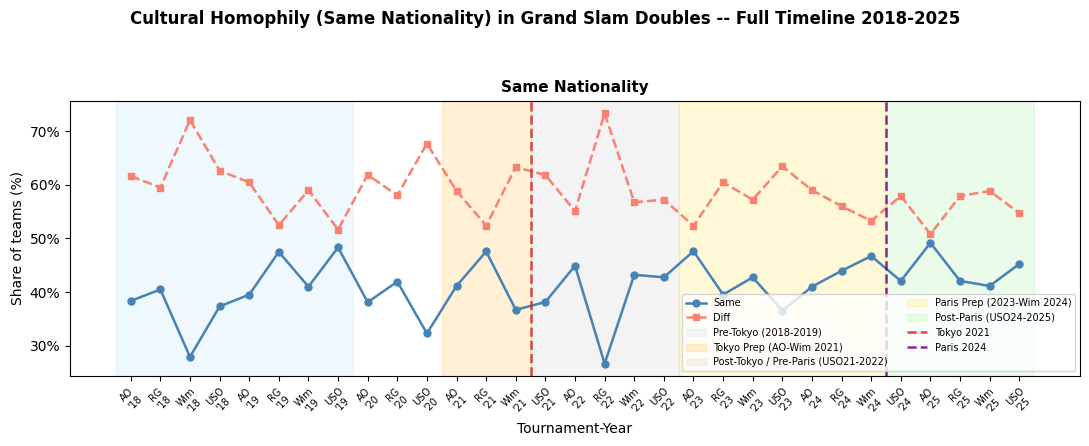

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(11, 4.5))
ac, ttl = avg_cols[0], titles[0]  # same_country_avg / 'Same Nationality'

ax.plot(ty_full['x'], ty_full[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
ax.plot(ty_full['x'], 100 - ty_full[ac], marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')

shades = [
    (mask_pre_tokyo,  'skyblue',    0.13, 'Pre-Tokyo (2018-2019)'),
    (mask_tokyo_prep, 'orange',     0.16, 'Tokyo Prep (AO-Wim 2021)'),
    (mask_interlude,  'lightgray',  0.25, 'Post-Tokyo / Pre-Paris (USO21-2022)'),
    (mask_paris_prep, 'gold',       0.16, 'Paris Prep (2023-Wim 2024)'),
    (mask_post_paris, 'lightgreen', 0.18, 'Post-Paris (USO24-2025)'),
]
for mask, color, alpha, lbl in shades:
    xs = ty_full.loc[mask, 'x']
    if not xs.empty:
        ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=alpha, color=color, label=lbl)

if len(x_wim21) and len(x_uso21):
    ax.axvline((x_wim21[0] + x_uso21[0]) / 2, color='#d62728', ls='--', lw=1.8, alpha=0.85, label='Tokyo 2021')
if len(x_wim24) and len(x_uso24):
    ax.axvline((x_wim24[0] + x_uso24[0]) / 2, color='purple',  ls='--', lw=1.8, alpha=0.85, label='Paris 2024')

ax.set_title(ttl, fontsize=11, fontweight='bold')
ax.set_xlabel('Tournament-Year')
ax.set_ylabel('Share of teams (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_xticks(ty_full['x'])
ax.set_xticklabels(ty_full['label'], fontsize=7)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=7, ncol=2, loc='lower right')

fig.suptitle('Cultural Homophily (Same Nationality) in Grand Slam Doubles -- Full Timeline 2018-2025',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('../../overleaf/plot/homophily_nationality_only.png', dpi=150, bbox_inches='tight')
plt.show()


## 6.4 Unique Partnerships per Tournament (Paper Table 2, Panel B)

Same rank-complete partnership base as Section 6 (N=2,101), grouped by tournament instead of
summed, for the paper's Table 2 per-tournament breakdown.


In [45]:
_p_ranked_check = partnerships.dropna(subset=['p1_rank', 'p2_rank'])
print('=== Unique partnerships per tournament (rank-complete, N=2,101 total) ===')
_by_tourn = _p_ranked_check.groupby('tournament').size().reindex(
    ['Australian Open', 'Roland Garros', 'Wimbledon', 'US Open'])
for t, n in _by_tourn.items():
    print(f'  {t:<18s} {n:5d}')
print(f'  {"Total":<18s} {_by_tourn.sum():5d}')


=== Unique partnerships per tournament (rank-complete, N=2,101 total) ===
  Australian Open      542
  Roland Garros        543
  Wimbledon            487
  US Open              517
  Total               2089
